# Кейсы в США с Pandas, Matplotlib и Seaborn

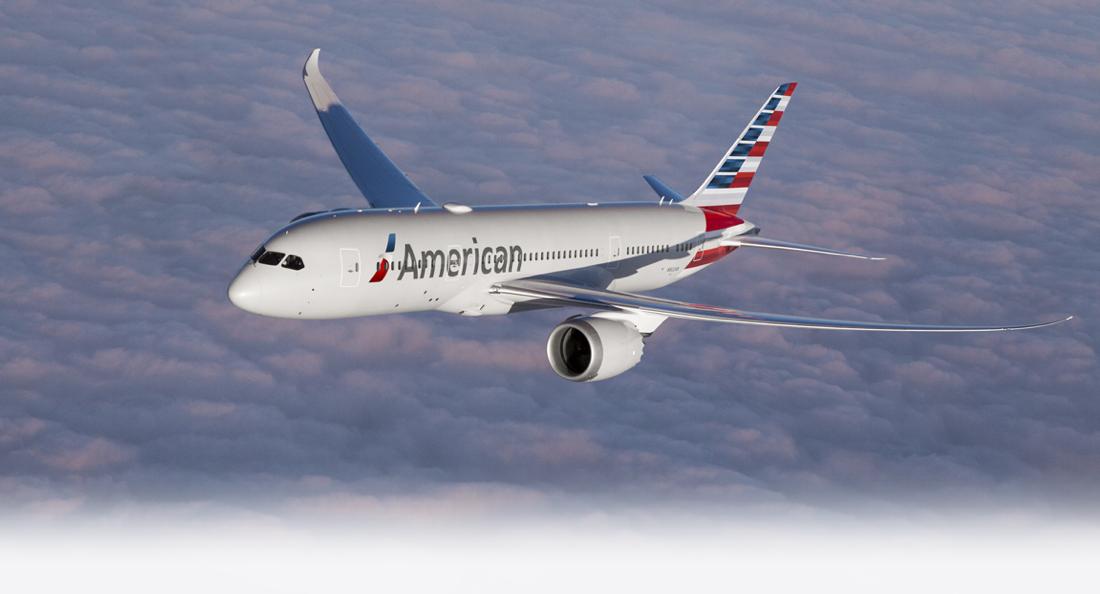

### Ваша задача:
- написать код и выполнить вычисления в ячейках ниже (там где будут вопросы)

In [60]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

sns.set()
%config InlineBackend.figure_format = 'retina'

* Скачать данные [архив](https://drive.google.com/file/d/1lGEDDVgD8QYMf9Fio_NG6jBWOF4Ttr7e/view?usp=sharing) (В архиве ~ 111 Мб, в разархивированном виде – ~ 690 Мб). Не нужно распаковывать — Pandas может сам это сделать.
* Поместите его в папку там где лежит ваш Jupyter.
* Набор данных содержит информацию о перевозчиках и рейсах между аэропортами США в течение 2008 года.
* Описание столбцов доступно [здесь] (https://www.transtats.bts.gov/Fields.asp?gnoyr_VQ=FGJ). Посетите этот сайт, чтобы найти значение кодов отмены рейса. И в целом лучше понимать что за данные у нас есть.

Рассмотрим следующие термины, которые мы используем:
* уникальный рейс – запись (строка) в наборе данных
* завершенный рейс – рейс, который не отменен (Cancelled==0 в наборе данных)
* код рейса – комбинация ['UniqueCarrier','FlightNum'], т.е. UA52
* код аэропорта – трехбуквенный псевдоним аэропорта из столбцов «Origin» или «Dest».

**Чтение данных и создание объекта Pandas ``DataFrame``**

(Это может занять некоторое время, будьте терпеливы)

Мы не собираемся читать весь набор данных. Чтобы уменьшить объем памяти, мы вместо этого загружаем только необходимые столбцы и приводим их к подходящим типам данных.

In [61]:
dtype = {
    "DayOfWeek": np.uint8,
    "DayofMonth": np.uint8,
    "Month": np.uint8,
    "Cancelled": np.uint8,
    "Year": np.uint16,
    "FlightNum": np.uint16,
    "Distance": np.uint16,
    "UniqueCarrier": str,
    "CancellationCode": str,
    "Origin": str,
    "Dest": str,
    "ArrDelay": np.float32,
    "DepDelay": np.float32,
    "CarrierDelay": np.float32,
    "WeatherDelay": np.float32,
    "NASDelay": np.float32,
    "SecurityDelay": np.float32,
    "LateAircraftDelay": np.float32,
    "DepTime": np.float32,
}

In [62]:
flights_df = pd.read_csv("flights_2008.csv.bz2", usecols=dtype.keys(), dtype=dtype)

**Проверьте количество строк и столбцов и распечатайте имена столбцов.**

In [63]:
print(flights_df.shape)
print(flights_df.columns)

(7009728, 19)
Index(['Year', 'Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'UniqueCarrier',
       'FlightNum', 'ArrDelay', 'DepDelay', 'Origin', 'Dest', 'Distance',
       'Cancelled', 'CancellationCode', 'CarrierDelay', 'WeatherDelay',
       'NASDelay', 'SecurityDelay', 'LateAircraftDelay'],
      dtype='str')


**Распечатайте первые 5 строк набора данных.**

In [64]:
flights_df.head()

,Year,Month,DayofMonth,DayOfWeek,DepTime,UniqueCarrier,FlightNum,ArrDelay,DepDelay,Origin,Dest,Distance,Cancelled,CancellationCode,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,2008,1,3,4,2003.0,WN,335,-14.0,8.0,IAD,TPA,810,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2008,1,3,4,754.0,WN,3231,2.0,19.0,IAD,TPA,810,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2008,1,3,4,628.0,WN,448,14.0,8.0,IND,BWI,515,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2008,1,3,4,926.0,WN,1746,-6.0,-4.0,IND,BWI,515,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2008,1,3,4,1829.0,WN,3920,34.0,34.0,IND,BWI,515,0,NaN,2.0,0.0,0.0,0.0,32.0


**Изучите типы данных всех столбцов.**

In [65]:
flights_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7009728 entries, 0 to 7009727
Data columns (total 19 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Year               uint16 
 1   Month              uint8  
 2   DayofMonth         uint8  
 3   DayOfWeek          uint8  
 4   DepTime            float32
 5   UniqueCarrier      str    
 6   FlightNum          uint16 
 7   ArrDelay           float32
 8   DepDelay           float32
 9   Origin             str    
 10  Dest               str    
 11  Distance           uint16 
 12  Cancelled          uint8  
 13  CancellationCode   str    
 14  CarrierDelay       float32
 15  WeatherDelay       float32
 16  NASDelay           float32
 17  SecurityDelay      float32
 18  LateAircraftDelay  float32
dtypes: float32(8), str(4), uint16(3), uint8(4)
memory usage: 494.7 MB


**Получите базовую статистику по каждому столбцу.**

In [66]:
flights_df.describe()

,Year,Month,DayofMonth,DayOfWeek,DepTime,FlightNum,ArrDelay,DepDelay,Distance,Cancelled,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
count,7009728.0,7.009728e+06,7.009728e+06,7.009728e+06,6.873482e+06,7.009728e+06,6.855029e+06,6.873482e+06,7.009728e+06,7.009728e+06,1.524735e+06,1.524735e+06,1.524735e+06,1.524735e+06,1.524735e+06
mean,2008.0,6.375130e+00,1.572801e+01,3.924182e+00,1.333830e+03,2.224200e+03,8.168452e+00,9.972570e+00,7.263870e+02,1.960618e-02,1.577206e+01,3.039031e+00,1.716462e+01,7.497434e-02,2.077098e+01
std,0.0,3.406737e+00,8.797068e+00,1.988259e+00,4.780689e+02,1.961716e+03,3.850194e+01,3.531127e+01,5.621018e+02,1.386426e-01,4.009912e+01,1.950287e+01,3.189495e+01,1.837940e+00,3.925964e+01
min,2008.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-5.190000e+02,-5.340000e+02,1.100000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2008.0,3.000000e+00,8.000000e+00,2.000000e+00,9.280000e+02,6.220000e+02,-1.000000e+01,-4.000000e+00,3.250000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2008.0,6.000000e+00,1.600000e+01,4.000000e+00,1.325000e+03,1.571000e+03,-2.000000e+00,-1.000000e+00,5.810000e+02,0.000000e+00,0.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,0.000000e+00
75%,2008.0,9.000000e+00,2.300000e+01,6.000000e+00,1.728000e+03,3.518000e+03,1.200000e+01,8.000000e+00,9.540000e+02,0.000000e+00,1.600000e+01,0.000000e+00,2.100000e+01,0.000000e+00,2.600000e+01
max,2008.0,1.200000e+01,3.100000e+01,7.000000e+00,2.400000e+03,9.743000e+03,2.461000e+03,2.467000e+03,4.962000e+03,1.000000e+00,2.436000e+03,1.352000e+03,1.357000e+03,3.920000e+02,1.316000e+03


**Подсчитайте уникальных перевозчиков и определите их относительную долю рейсов:**

In [67]:
flights_df["UniqueCarrier"].nunique()

20

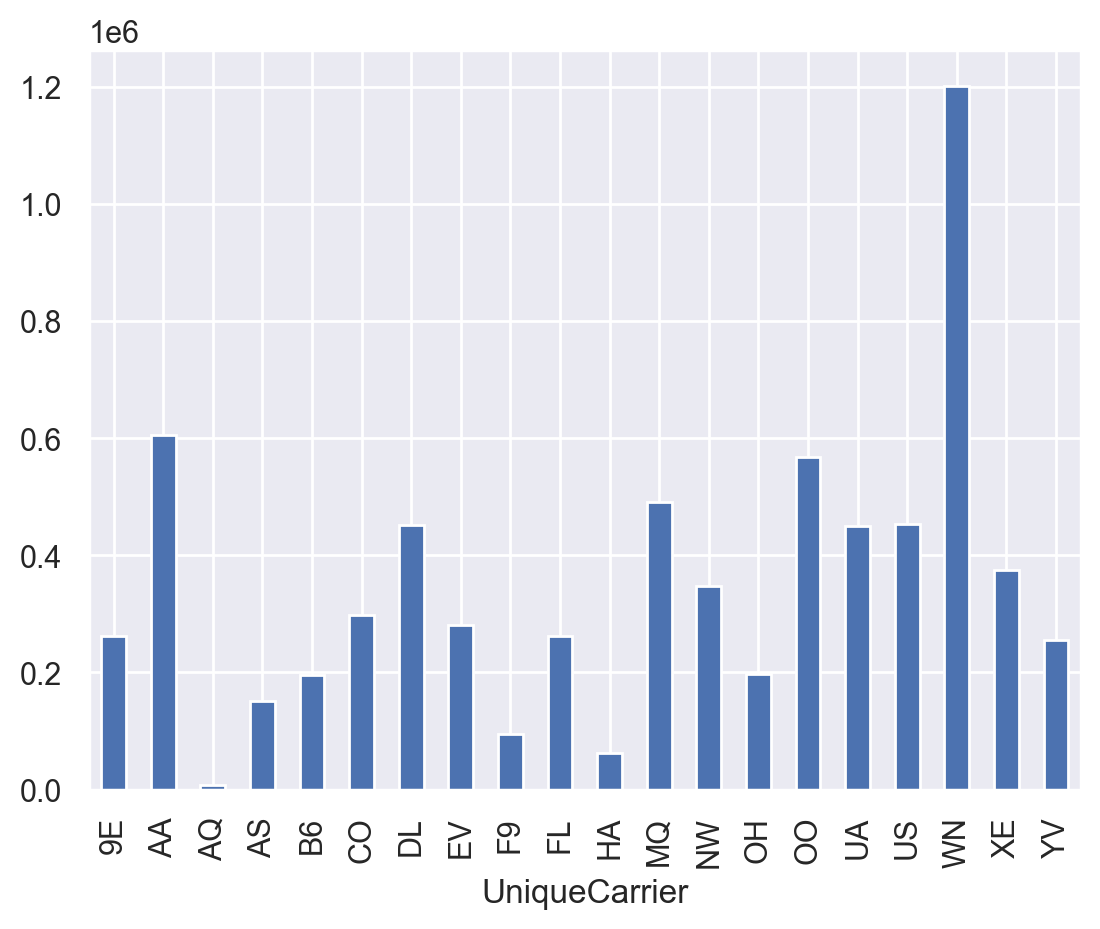

In [68]:
# Количество рейсов по перевозчикам 
flights_df.groupby("UniqueCarrier").size().plot(kind="bar");

**Мы также можем группировать по категориям, чтобы рассчитывать различные агрегированные статистические данные.**

**Например, поиск топ-3 кодов рейсов с наибольшим общим расстоянием, пройденным в 2008 году.**

In [69]:
flights_df.groupby(["UniqueCarrier", "FlightNum"])["Distance"].sum().sort_values(ascending=False).iloc[:3]

UniqueCarrier  FlightNum
CO             15           1796244
               14           1796244
UA             52           1789722
Name: Distance, dtype: uint64

**Другой способ:**

In [70]:
flights_df.groupby(["UniqueCarrier", "FlightNum"]).agg({"Distance": [np.mean, np.sum, "count"], "Cancelled": np.sum}
                                                      ).sort_values(("Distance", "sum"), ascending=False).iloc[0:3]

Distance                Cancelled
                                mean      sum count       sum
UniqueCarrier FlightNum                                      
CO            15         4962.000000  1796244   362         0
              14         4962.000000  1796244   362         0
UA            52         2465.181818  1789722   726         8

**Количество рейсов по дням недели и месяцам:**

In [71]:
pd.crosstab(flights_df.Month, flights_df.DayOfWeek)

DayOfWeek,1,2,3,4,5,6,7
Month,,,,,,,
1,80807,97298,100080,102043,81940,67178,76419
2,81504,79700,80587,82158,102726,66462,76099
3,103210,81159,82307,82831,82936,86153,97494
4,82463,100785,102586,82799,82964,68304,78225
5,80626,79884,81264,102572,102878,84493,74576
6,104168,82160,82902,83617,83930,72322,99566
7,84095,103429,103315,105035,79349,72219,80489
8,82983,80895,81773,82625,103878,86155,93970
9,94300,91533,74057,75589,75881,58343,71205


**Гистограмма дальности полета:**

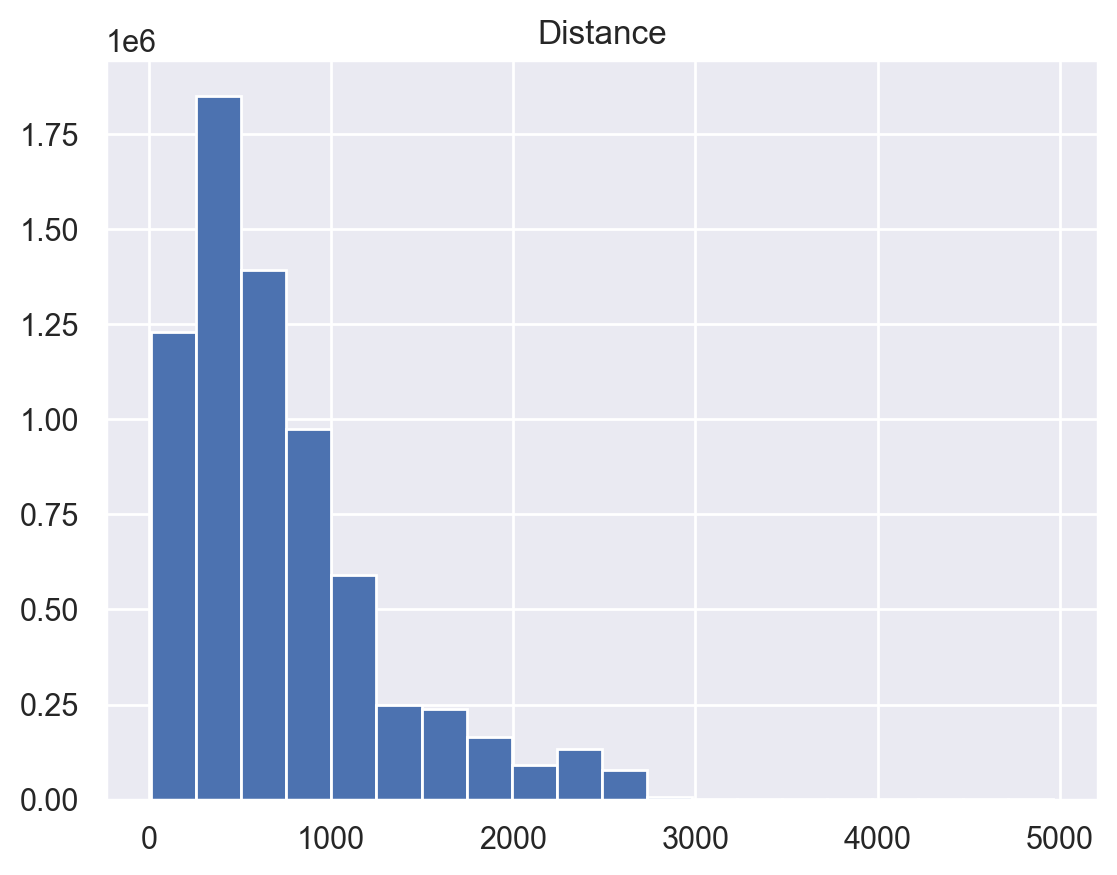

In [72]:
flights_df.hist("Distance", bins=20);

**Составление гистограммы частоты рейсов по дате.**

In [73]:
flights_df["Date"] = pd.to_datetime(
    flights_df.rename(columns={"DayofMonth": "Day"})[["Year", "Month", "Day"]]
)

In [74]:
flights_df.head()

,Year,Month,DayofMonth,DayOfWeek,DepTime,UniqueCarrier,FlightNum,ArrDelay,DepDelay,Origin,Dest,Distance,Cancelled,CancellationCode,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,Date
0,2008,1,3,4,2003.0,WN,335,-14.0,8.0,IAD,TPA,810,0,NaN,NaN,NaN,NaN,NaN,NaN,2008-01-03
1,2008,1,3,4,754.0,WN,3231,2.0,19.0,IAD,TPA,810,0,NaN,NaN,NaN,NaN,NaN,NaN,2008-01-03
2,2008,1,3,4,628.0,WN,448,14.0,8.0,IND,BWI,515,0,NaN,NaN,NaN,NaN,NaN,NaN,2008-01-03
3,2008,1,3,4,926.0,WN,1746,-6.0,-4.0,IND,BWI,515,0,NaN,NaN,NaN,NaN,NaN,NaN,2008-01-03
4,2008,1,3,4,1829.0,WN,3920,34.0,34.0,IND,BWI,515,0,NaN,2.0,0.0,0.0,0.0,32.0,2008-01-03


In [75]:
num_flights_by_date = flights_df.groupby("Date").size()

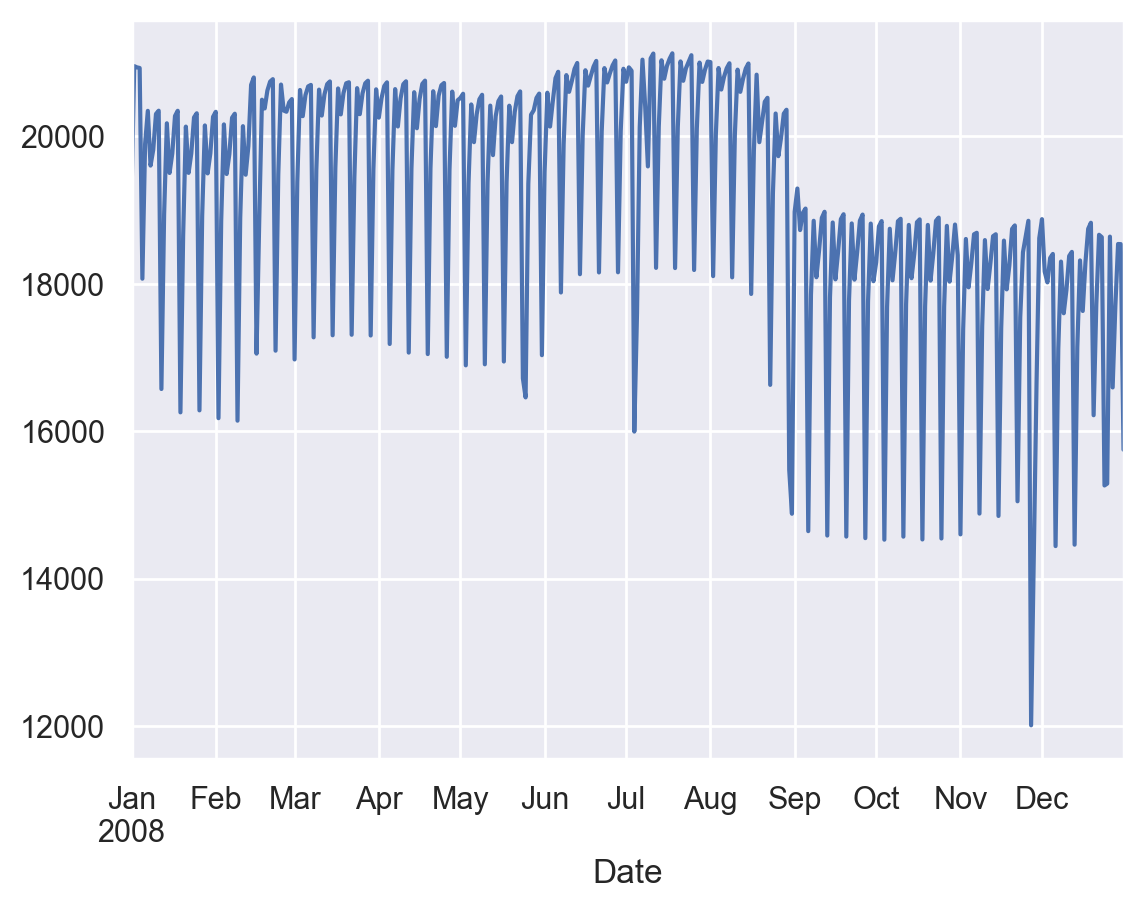

In [76]:
num_flights_by_date.plot();

**Видите ли вы какую-то зависимость по неделям, еженедельную динамику выше? И ниже?**

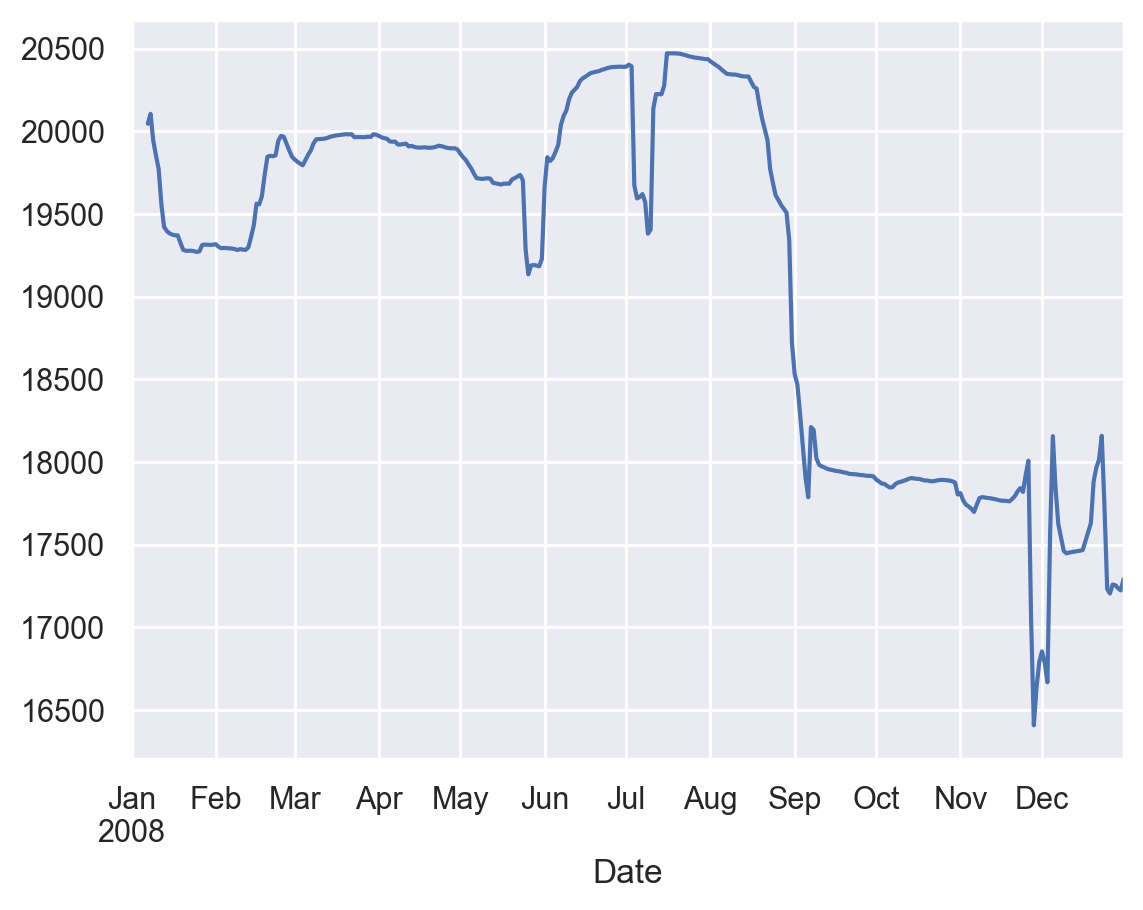

In [77]:
num_flights_by_date.rolling(window=7).mean().plot();

**Нам понадобится новый столбец в нашем наборе данных — час отправления, давайте создадим его.**

Как мы видим, `DepTime` распределяется от 1 до 2400 (оно задаётся в формате `hhmm`, проверьте [описание столбца](https://www.transtats.bts.gov/Fields.asp?Table_ID=236 ) снова). Мы будем рассматривать час отправления как `DepTime` // 100 (разделите на 100 и примените функцию `floor`). Однако теперь у нас будет и час 0, и час 24. Час 24 звучит странно, вместо этого мы установим его равным 0 (типичное несовершенство реальных данных, однако вы можете проверить, что оно влияет только на 521 строку, что вроде ничего страшного). Итак, теперь значения нового столбца `DepHour` будут распределены от 0 до 23. Есть некоторые недостающие значения, пока мы не будем их заполнять, а просто проигнорируем.

In [78]:
flights_df["DepHour"] = flights_df["DepTime"] // 100
flights_df["DepHour"].replace(to_replace=24, value=0, inplace=True)
flights_df.head()

C:\Users\Gulsara\AppData\Local\Temp\ipykernel_5104\796107878.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  flights_df["DepHour"].replace(to_replace=24, value=0, inplace=True)


,Year,Month,DayofMonth,DayOfWeek,DepTime,UniqueCarrier,FlightNum,ArrDelay,DepDelay,Origin,...,Distance,Cancelled,CancellationCode,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,Date,DepHour
0,2008,1,3,4,2003.0,WN,335,-14.0,8.0,IAD,...,810,0,NaN,NaN,NaN,NaN,NaN,NaN,2008-01-03,20.0
1,2008,1,3,4,754.0,WN,3231,2.0,19.0,IAD,...,810,0,NaN,NaN,NaN,NaN,NaN,NaN,2008-01-03,7.0
2,2008,1,3,4,628.0,WN,448,14.0,8.0,IND,...,515,0,NaN,NaN,NaN,NaN,NaN,NaN,2008-01-03,6.0
3,2008,1,3,4,926.0,WN,1746,-6.0,-4.0,IND,...,515,0,NaN,NaN,NaN,NaN,NaN,NaN,2008-01-03,9.0
4,2008,1,3,4,1829.0,WN,3920,34.0,34.0,IND,...,515,0,NaN,2.0,0.0,0.0,0.0,32.0,2008-01-03,18.0


In [79]:
flights_df["DepHour"].describe()

count    6.873482e+06
mean     1.303919e+01
std      4.789549e+00
min      0.000000e+00
25%      9.000000e+00
50%      1.300000e+01
75%      1.700000e+01
max      2.400000e+01
Name: DepHour, dtype: float64

# Теперь твоя очередь. Ответить на вопросы ниже.

**<font color='red'>Вопрос 1.</font> Набор данных включает как отмененные, так и завершенные рейсы. Определите, есть ли больше выполненных или отмененных рейсов, и посчитайте числовую разницу между ними.** <br>

- Отмененных рейсов больше, чем выполненных на 329.
- Выполнено рейсов больше отмененных на 6 734 860.
- Отмененные рейсы превышают выполненные на 671.
- Выполнено рейсов больше, чем отменено на 11 088 967.

In [80]:
num_cancelled = flights_df["Cancelled"].sum()
num_completed = len(flights_df) - num_cancelled
print(f"Выполненных рейсов: {num_completed}")
print(f"Отмененных рейсов: {num_cancelled}")

difference = num_completed - num_cancelled
print(f"Разница между выполненными и отмененными рейсами: {difference}")

Выполненных рейсов: 6872294
Отмененных рейсов: 137434
Разница между выполненными и отмененными рейсами: 6734860


**<font color='red'>Вопрос 2.</font> Найдите рейс с наибольшей задержкой вылета и рейс с наибольшей задержкой прибытия. Летят ли они в один аэропорт, и если да, то какой у него код?**

- да, ATL
- да, HNL
- да, MSP
- нет

In [81]:
max_dep_delay_flight = flights_df.loc[flights_df["DepDelay"].idxmax()]
max_arr_delay_flight = flights_df.loc[flights_df["ArrDelay"].idxmax()]
print("Рейс с наибольшей задержкой вылета:")
print(max_dep_delay_flight[["UniqueCarrier", "FlightNum", "ArrDelay", "DepDelay", "Origin", "Dest", "Distance"]])
print("\nРейс с наибольшей задержкой прибытия:")
print(max_arr_delay_flight[["UniqueCarrier", "FlightNum", "ArrDelay", "DepDelay", "Origin", "Dest", "Distance"]])

if max_dep_delay_flight["Dest"] == max_arr_delay_flight["Dest"]:
    print(f"\nОба рейса летят в один аэропорт: {max_dep_delay_flight['Dest']}")
else:
    print("\nРейсы не летят в один аэропорт.")

Рейс с наибольшей задержкой вылета:
UniqueCarrier        NW
FlightNum          1699
ArrDelay         2453.0
DepDelay         2467.0
Origin              CLT
Dest                MSP
Distance            930
Name: 2235378, dtype: object

Рейс с наибольшей задержкой прибытия:
UniqueCarrier        NW
FlightNum           808
ArrDelay         2461.0
DepDelay         2457.0
Origin              HNL
Dest                MSP
Distance           3972
Name: 1018798, dtype: object

Оба рейса летят в один аэропорт: MSP


**<font color='red'>Вопрос 3.</font> Найдите перевозчика, у которого наибольшее количество отмененных рейсов.**

- АА
- MQ
- ВН
- СО

In [82]:
# Найдите перевозчика, у которого наибольшее количество отмененных рейсов.

cancellations_by_carrier = flights_df.groupby("UniqueCarrier")["Cancelled"].sum()
max_cancellations_carrier = cancellations_by_carrier.idxmax()
print(f"Перевозчик с наибольшим количеством отмененных рейсов: {max_cancellations_carrier} ({cancellations_by_carrier[max_cancellations_carrier]} отмененных рейсов)")



Перевозчик с наибольшим количеством отмененных рейсов: MQ (18331 отмененных рейсов)


**<font color='red'>Вопрос 4.</font> Давайте рассмотрим время отправления и рассмотрим распределение по часам (столбец `DepHour`, который мы создали ранее). В какой час самый высокий процент рейсов?**<br>

*Подсказка:* Проверьте формат времени [здесь](https://www.transtats.bts.gov/Fields.asp?gnoyr_VQ=FGJ).

- 1 am 
- 5 am  
- 8 am 
- 3 pm 

Час с наибольшим процентом рейсов: 8.0 am (6.54%)

Процент рейсов по часам:
 12 am :   0.29%
1.0 am :   0.09%
2.0 am :   0.03%
3.0 am :   0.01%
4.0 am :   0.05%
5.0 am :   2.16%
6.0 am :   6.50%
7.0 am :   6.35%
8.0 am :   6.54%
9.0 am :   6.33%
10.0 am :   6.28%
11.0 am :   6.47%
 12 pm :   6.17%
1.0 pm :   6.34%
2.0 pm :   6.06%
3.0 pm :   5.98%
4.0 pm :   6.31%
5.0 pm :   6.29%
6.0 pm :   5.83%
7.0 pm :   5.63%
8.0 pm :   4.16%
9.0 pm :   3.71%
10.0 pm :   1.74%
11.0 pm :   0.67%
12.0 pm :   0.01%


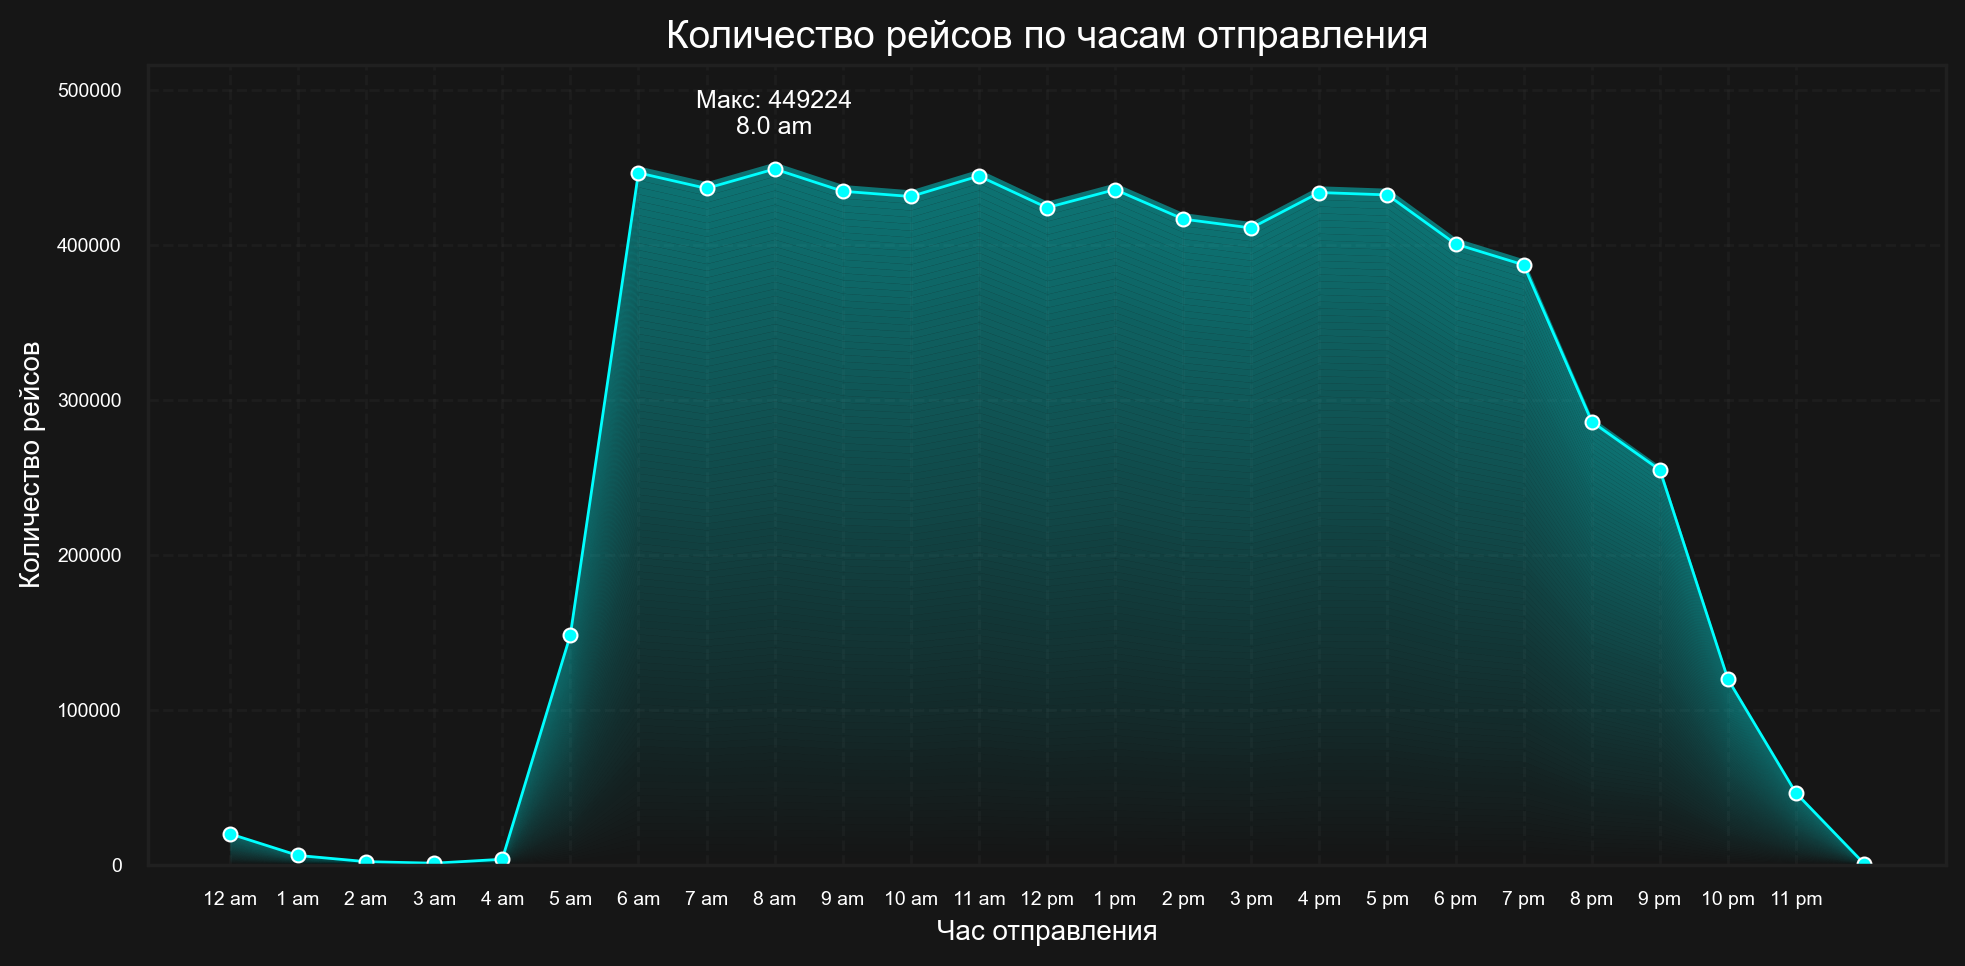

In [83]:
def hour_to_ampm(hour):
    if hour == 0:
        return "12 am"
    elif hour < 12:
        return f"{hour} am"
    elif hour == 12:
        return "12 pm"
    else:
        return f"{hour - 12} pm"

flights_by_hour = flights_df.groupby("DepHour").size()
percentage_by_hour = (flights_by_hour / flights_by_hour.sum()) * 100

# Найдем час с наибольшим процентом рейсов
max_hour = percentage_by_hour.idxmax()
max_percentage = percentage_by_hour[max_hour]

print(f"Час с наибольшим процентом рейсов: {hour_to_ampm(max_hour)} ({max_percentage:.2f}%)")
print("\nПроцент рейсов по часам:")
for hour in sorted(percentage_by_hour.index):
    print(f"{hour_to_ampm(hour):>6} : {percentage_by_hour[hour]:>6.2f}%")

fig, ax = plt.subplots(figsize=(10, 5), facecolor="#161616")
ax.set_facecolor("#161616")
sns.lineplot(x=flights_by_hour.index, y=flights_by_hour.values, linewidth=1, marker='o', markersize=5, ax=ax, color="#00ffff")

for spine in ax.spines.values():
    spine.set_color("#202020")

for i in range(len(flights_by_hour) - 1):
    x = [flights_by_hour.index[i], flights_by_hour.index[i+1]]
    y = [flights_by_hour.values[i], flights_by_hour.values[i+1]]

    for alpha, frac in zip(np.linspace(0.4, 0, 100), np.linspace(0, 1, 100)):
        y_lower = [v * frac for v in y]
        y_upper = [v * (frac + 0.01) for v in y]

        ax.fill_between(
            x,
            y_lower,
            y_upper,
            color="#00ffff96",
            alpha=0.4 - alpha,
            linewidth=0
        )

# Добавляем аннотацию максимального значения
max_value = flights_by_hour.max()
max_index = flights_by_hour.idxmax()
ax.annotate(f'Макс: {max_value}\n{hour_to_ampm(max_index)}', 
             xy=(max_index, max_value),
             xytext=(max_index, max_value*1.05),
             ha='center',
             fontsize=9,
             color="#FFFFFF",
             bbox=dict(boxstyle='round,pad=0.5', facecolor="none", alpha=0.7, edgecolor='none'))

ax.set_xlabel("Час отправления", fontsize=10, color='white')
ax.set_ylabel("Количество рейсов", fontsize=10, color='white')
ax.set_title("Количество рейсов по часам отправления", fontsize=14, color='white')
ax.set_xticks(range(0, 24))
ax.set_xticklabels([hour_to_ampm(h) for h in range(0, 24)], rotation=0, color='white', fontsize=7)
ax.tick_params(colors='white', labelsize=7)
ax.set_ylim(0, flights_by_hour.max() * 1.15)
ax.grid(True, alpha=0.2, color="#3b3b3b", linestyle='--')
plt.tight_layout()
plt.show()

**<font color='red'>Вопрос 5.</font> Хорошо, теперь давайте рассмотрим распределение отмененных рейсов по времени. В какой час наименьший процент отмененных рейсов?**<br>

- 2 am 
- 9 pm  
- 8 am  
- 3 am

Час с наименьшим процентом отмененных рейсов: 3.0 am (0.00%)

Процент отмененных рейсов по часам:
 12 am :   0.04%
1.0 am :   0.07%
2.0 am :   0.05%
3.0 am :   0.00%
4.0 am :   0.03%
5.0 am :   0.02%
6.0 am :   0.02%
7.0 am :   0.02%
8.0 am :   0.02%
9.0 am :   0.01%
10.0 am :   0.01%
11.0 am :   0.01%
 12 pm :   0.01%
1.0 pm :   0.01%
2.0 pm :   0.01%
3.0 pm :   0.02%
4.0 pm :   0.02%
5.0 pm :   0.02%
6.0 pm :   0.02%
7.0 pm :   0.02%
8.0 pm :   0.02%
9.0 pm :   0.03%
10.0 pm :   0.05%
11.0 pm :   0.05%
12.0 pm :   0.00%


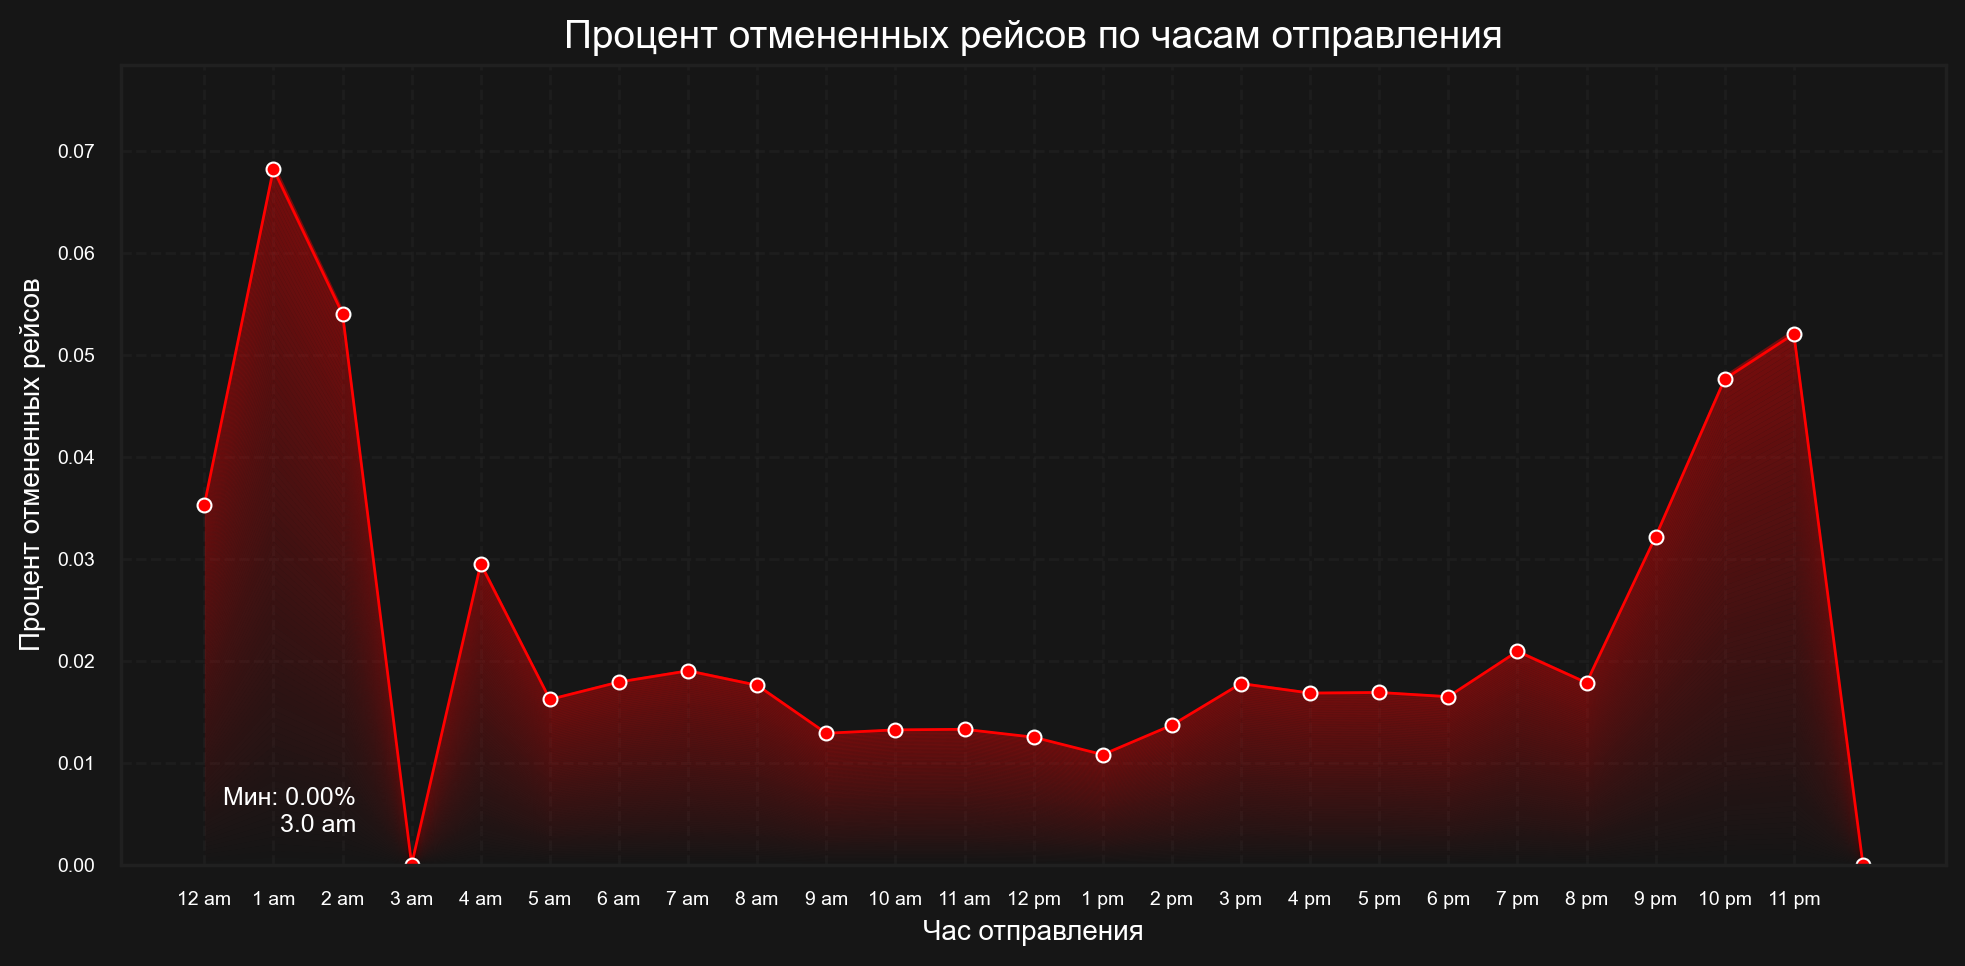

In [84]:
cancellations_by_hour = flights_df.groupby("DepHour")["Cancelled"].sum()
total_flights_by_hour = flights_df.groupby("DepHour").size()
percentage_cancellations_by_hour = (cancellations_by_hour / total_flights_by_hour) * 100

# Найдем час с наименьшим процентом отмененных рейсов
min_hour = percentage_cancellations_by_hour.idxmin()
min_percentage = percentage_cancellations_by_hour[min_hour]

print(f"Час с наименьшим процентом отмененных рейсов: {hour_to_ampm(min_hour)} ({min_percentage:.2f}%)")
print("\nПроцент отмененных рейсов по часам:")
for hour in sorted(percentage_cancellations_by_hour.index):
    print(f"{hour_to_ampm(hour):>6} : {percentage_cancellations_by_hour[hour]:>6.2f}%")

# Построим график
fig, ax = plt.subplots(figsize=(10, 5), facecolor="#161616")
ax.set_facecolor("#161616")
sns.lineplot(x=percentage_cancellations_by_hour.index, y=percentage_cancellations_by_hour.values, linewidth=1, marker='o', markersize=5, ax=ax, color="#ff0000")

for spine in ax.spines.values():
    spine.set_color("#202020")

for i in range(len(percentage_cancellations_by_hour) - 1):
    x = [percentage_cancellations_by_hour.index[i], percentage_cancellations_by_hour.index[i+1]]
    y = [percentage_cancellations_by_hour.values[i], percentage_cancellations_by_hour.values[i+1]]

    for alpha, frac in zip(np.linspace(0.4, 0, 100), np.linspace(0, 1, 100)):
        y_lower = [v * frac for v in y]
        y_upper = [v * (frac + 0.01) for v in y]

        ax.fill_between(
            x,
            y_lower,
            y_upper,
            color="#ff000096",
            alpha=0.4 - alpha,
            linewidth=0
        )

# Добавляем аннотацию минимального значения
min_value = percentage_cancellations_by_hour.min()
min_index = percentage_cancellations_by_hour.idxmin()
ax.annotate(
    f'Мин: {min_value:.2f}%\n{hour_to_ampm(min_index)}',
    xy=(min_index, min_value),
    xytext=(-20, 10),
    textcoords='offset points',
    ha='right',
    va='bottom',
    fontsize=9,
    color="#FFFFFF",
    bbox=dict(boxstyle='round,pad=0.5', facecolor='none', alpha=0.7, edgecolor='none'))

ax.set_xlabel("Час отправления", fontsize=10, color='white')
ax.set_ylabel("Процент отмененных рейсов", fontsize=10, color='white')
ax.set_title("Процент отмененных рейсов по часам отправления", fontsize=14, color='white')
ax.set_xticks(range(0, 24))
ax.set_xticklabels([hour_to_ampm(h) for h in range(0, 24)], rotation=0, color='white', fontsize=7)
ax.tick_params(colors='white', labelsize=7)
ax.set_ylim(0, percentage_cancellations_by_hour.max() * 1.15)
ax.grid(True, alpha=0.2, color="#3b3b3b", linestyle='--')
plt.tight_layout()

**<font color='red'>Вопрос 6.</font> Есть ли какой-нибудь час, в который вообще не было отмененных рейсов? Проверить все, что относится.**

- 3
- 19
- 22
- 4

In [85]:
hours_with_no_cancellations = percentage_cancellations_by_hour[percentage_cancellations_by_hour == 0].index
if len(hours_with_no_cancellations) > 0:
    print("\nЧасы, в которые не было отмененных рейсов:")
    for hour in hours_with_no_cancellations:
        print(f"{hour_to_ampm(hour)}")


Часы, в которые не было отмененных рейсов:
3.0 am
12.0 pm


**<font color='red'>Вопрос 7.</font> Найдите самый загруженный час или, другими словами, час, когда количество вылетающих рейсов достигает максимума.**<br>

*Подсказка:* Учитывайте только *завершенные* рейсы.

- 4
- 7
- 8
- 17

In [86]:
completed_flights_by_hour = (flights_df[flights_df["Cancelled"] == 0].groupby("DepHour").size())
max_load_hour = completed_flights_by_hour.idxmax()

print(f"\nЧас с наибольшей загрузкой (наибольшим количеством выполненных рейсов): {hour_to_ampm(max_load_hour)} ({completed_flights_by_hour[max_load_hour]} выполненных рейсов)")


Час с наибольшей загрузкой (наибольшим количеством выполненных рейсов): 8.0 am (449145 выполненных рейсов)


**<font color='red'>Вопрос 8.</font> Поскольку мы знаем час отправления, было бы интересно изучить среднюю задержку для соответствующего часа. Бывают ли случаи, когда самолеты в среднем вылетали раньше положенного? И если да, то в какое время это произошло?**<br>

*Подсказка:* Учитывайте только *завершенные* рейсы.

- нет, таких случаев не бывает
- да, в 5-6 утра
- да, в 9-10 утра
- да, в 14-16.00

In [87]:
# Отобрать только завершённые рейсы
completed_flights = flights_df[flights_df["Cancelled"] == 0]

# Рассчитать среднюю задержку вылета по каждому часу
delay_by_hour = completed_flights.groupby("DepHour")["DepDelay"].mean()

# Проверить наличие отрицательных средних задержек
negative_delays = delay_by_hour < 0

# Найти час с минимальной средней задержкой
min_delay_hour = delay_by_hour.idxmin()
min_delay_value = delay_by_hour[min_delay_hour]

if negative_delays.any():
    print("\nЧасы, в которые самолёты в среднем вылетали раньше расписания:")
    for hour in delay_by_hour[negative_delays].index:
        print(f"{hour_to_ampm(hour)}: {delay_by_hour[hour]:.2f} минут")
    print(f"\nНаиболее ранние вылеты наблюдались в {hour_to_ampm(min_delay_hour)} со средней задержкой {min_delay_value:.2f} минут.")


Часы, в которые самолёты в среднем вылетали раньше расписания:
5.0 am: -4.26 минут
6.0 am: -1.63 минут

Наиболее ранние вылеты наблюдались в 5.0 am со средней задержкой -4.26 минут.


**<font color='red'>Вопрос 9.</font> Учитывая только выполненные перевозчиком рейсы, которые вы нашли в вопросе 3, найдите распределение этих рейсов по часам. В какое время вылетает наибольшее количество самолетов?**<br>

- в полдень
- в 7 утра
- в 8 утра
- в 10 утра

Самое большое количество рейсов перевозчика MQ в: 10.0 am (33063 рейсов)


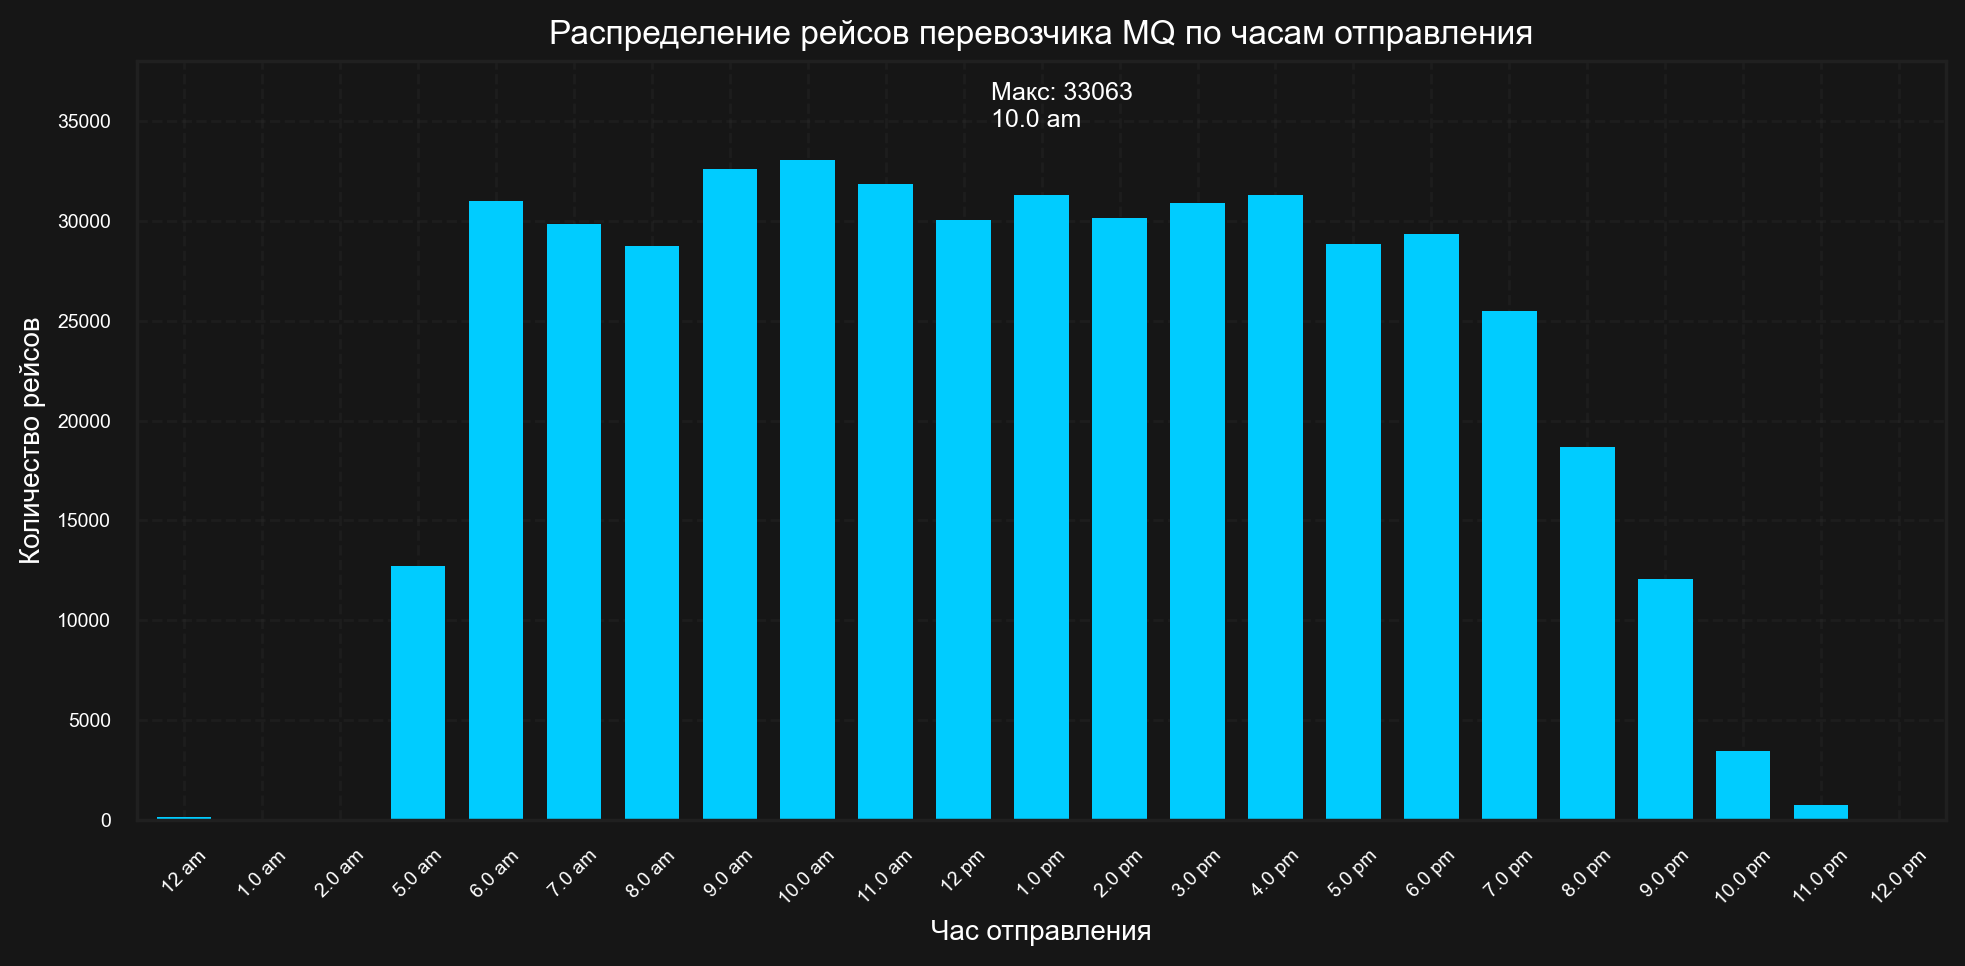

In [88]:
# Отобираем рейсы нужного перевозчика
selected_airline_flights = flights_df[flights_df["UniqueCarrier"] == "MQ"]
# Оставляем только выполненные рейсы
selected_airline_flights = selected_airline_flights[selected_airline_flights["Cancelled"] == 0]
# Группируем рейсы по часу вылета
flights_by_hour_mq = selected_airline_flights.groupby("DepHour").size()

# Найдем час с максимальным количеством рейсов
max_hour_mq = flights_by_hour_mq.idxmax()
max_value_mq = flights_by_hour_mq.max()
print(f"Самое большое количество рейсов перевозчика MQ в: {hour_to_ampm(max_hour_mq)} ({max_value_mq} рейсов)")

# Строим столбчатый график с темным оформлением
fig, ax = plt.subplots(figsize=(10, 5), facecolor="#161616")
ax.set_facecolor("#161616")

# Построение столбчатого графика
flights_by_hour_mq.plot(kind="bar", ax=ax, color="#00ccff", width=0.7, edgecolor='none')

# Оформление границ
for spine in ax.spines.values():
    spine.set_color("#202020")

# Добавляем аннотацию максимального значения
max_value_bar = flights_by_hour_mq.max()
max_index_bar = flights_by_hour_mq.idxmax()
ax.annotate(
    f'Макс: {max_value_bar}\n{hour_to_ampm(max_index_bar)}',
    xy=(max_index_bar, max_value_bar),
    xytext=(10, 10),
    textcoords='offset points',
    ha='left',
    va='bottom',
    fontsize=9,
    color="#FFFFFF",
    bbox=dict(boxstyle='round,pad=0.5', facecolor='none', alpha=0.7, edgecolor='none'))

# Оформление осей и текста
ax.set_xlabel("Час отправления", fontsize=10, color='white')
ax.set_ylabel("Количество рейсов", fontsize=10, color='white')
ax.set_title("Распределение рейсов перевозчика MQ по часам отправления", fontsize=12, color='white')
ax.set_xticklabels([hour_to_ampm(h) for h in flights_by_hour_mq.index], rotation=45, color='white', fontsize=7)
ax.tick_params(colors='white', labelsize=7)

ax.set_ylim(0, flights_by_hour_mq.max() * 1.15)

# Сетка
ax.grid(True, alpha=0.2, color="#3b3b3b", linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

**<font color='red'>Вопрос 10.</font> Найдите топ-10 перевозчиков по количеству *выполненных* рейсов (столбец _UniqueCarrier_)?**

**Что из перечисленного ниже _нет_ в вашем списке топ-10?**
- DL
- AA
- OO
- EV 

In [89]:
top_10_carriers = flights_df[flights_df["Cancelled"] == 0].groupby("UniqueCarrier").size().nlargest(10)
print("Топ-10 перевозчиков по количеству выполненных рейсов:")
for carrier, count in top_10_carriers.items():
    print(f"{carrier}: {count} выполненных рейсов")

print("\nПроверка наличия перевозчиков в топ-10:")
for carrier in ["DL", "AA", "OO", "EV"]:
    if carrier in top_10_carriers.index:
        print(f"{carrier} - Входит в топ-10")
    else:
        print(f"{carrier} - Не входит в топ-10")



Топ-10 перевозчиков по количеству выполненных рейсов:
WN: 1189365 выполненных рейсов
AA: 587445 выполненных рейсов
OO: 554723 выполненных рейсов
MQ: 472362 выполненных рейсов
US: 447007 выполненных рейсов
DL: 445118 выполненных рейсов
UA: 438974 выполненных рейсов
XE: 364518 выполненных рейсов
NW: 344746 выполненных рейсов
CO: 294753 выполненных рейсов

Проверка наличия перевозчиков в топ-10:
DL - Входит в топ-10
AA - Входит в топ-10
OO - Входит в топ-10
EV - Не входит в топ-10


**<font color='red'>Вопрос 11.</font> Постройте распределение причин отмены рейса (CancellationCode).**

**Какая наиболее частая причина отмены рейса?**
- Перевозчик
- Погодные условия
- Национальная воздушная система
- Причины безопасности

Для выполнения данного задания создайте словарь с причинами отмен рейсов:

In [90]:
cancellation_descriptions = {
    'A': 'Carrier',
    'B': 'Weather',
    'C': 'National Air System',
    'D': 'Security'
}


Распределение причин отмены рейса:
B (Weather): 54904 отмененных рейсов (39.95%)
A (Carrier): 54330 отмененных рейсов (39.53%)
C (National Air System): 28188 отмененных рейсов (20.51%)
D (Security): 12 отмененных рейсов (0.01%)


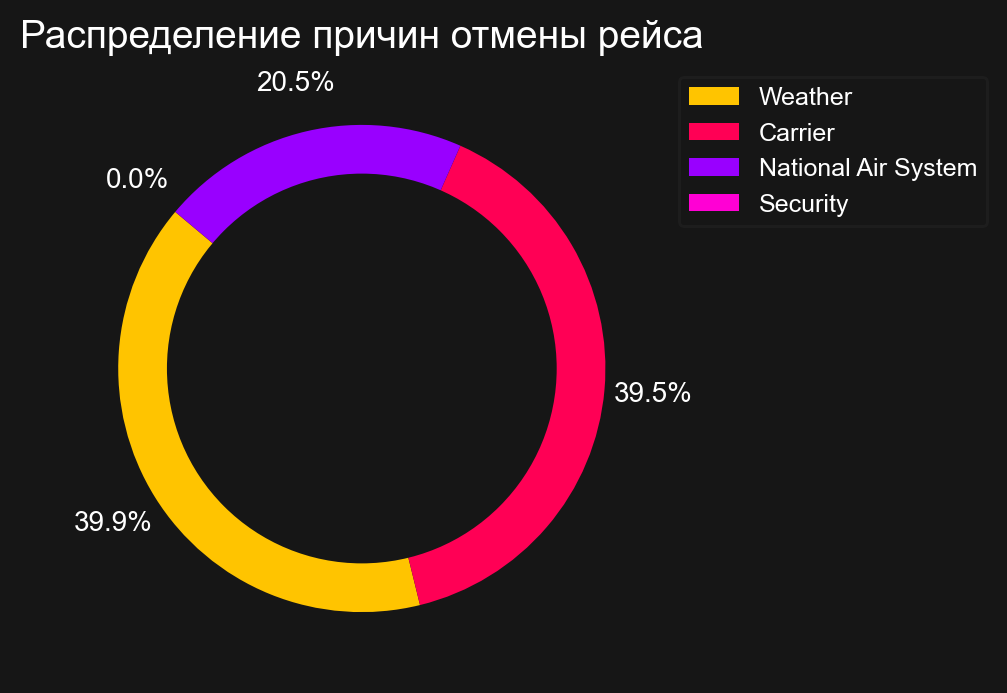


Наиболее частая причина отмены рейса:
B (Weather) - 54904 отмененных рейсов (39.95%)


In [91]:
cancellation_counts = flights_df[flights_df["Cancelled"] == 1]["CancellationCode"].value_counts()
cancellation_percentages = (cancellation_counts / cancellation_counts.sum()) * 100
print("\nРаспределение причин отмены рейса:")
for code, count in cancellation_counts.items():
    description = cancellation_descriptions.get(code, "Unknown")
    percentage = cancellation_percentages[code]
    print(f"{code} ({description}): {count} отмененных рейсов ({percentage:.2f}%)")

# Строим график
fig, ax = plt.subplots(figsize=(5, 5), facecolor="#161616")
ax.set_facecolor("#161616")
colors = ["#ffc400", "#ff0055", "#9900ff", "#ff00d4"]
cancellation_counts.plot(kind="pie", ax=ax, colors=colors, autopct='%1.1f%%', startangle=140, pctdistance=1.2, labels=None, textprops={'color': 'white', 'fontsize': 10}, wedgeprops={'edgecolor': 'none'})
# Рисуем белый круг в центре
centre_circle = plt.Circle((0, 0), 0.80, fc="#161616",edgecolor='none')
fig.gca().add_artist(centre_circle)
ax.set_title("Распределение причин отмены рейса", fontsize=14, color='white')
ax.set_ylabel("")

# Добавляем легенду с описаниями
legend_labels = [cancellation_descriptions.get(code, "Unknown") for code in cancellation_counts.index]
ax.legend(legend_labels, loc='upper left', bbox_to_anchor=(1, 1), fontsize=9, labelcolor='white', facecolor='#161616', edgecolor='#202020')

plt.tight_layout()
plt.show()

# Какая наиболее частая причина отмены рейса?
print("\nНаиболее частая причина отмены рейса:")
most_common_cancellation_code = cancellation_counts.idxmax()
most_common_cancellation_description = cancellation_descriptions.get(most_common_cancellation_code, "Unknown")
print(f"{most_common_cancellation_code} ({most_common_cancellation_description}) - {cancellation_counts[most_common_cancellation_code]} отмененных рейсов ({cancellation_percentages[most_common_cancellation_code]:.2f}%)")

**<font color='red'>Вопрос 12.</font> Какой маршрут наиболее частый по количеству рейсов?**

(Обратите внимание на столбцы _'Origin'_ и _'Dest'_. Рассматривайте направления _A->B_ и _B->A_ как _разные_ маршруты)

  - Нью-Йорк – Вашингтон (JFK-IAD)
  - Сан-Франциско – Лос-Анджелес (SFO-LAX)
  - Сан-Хосе – Даллас (SJC-DFW)
  - Нью-Йорк – Сан-Франциско (JFK-SFO)

In [92]:
flights_df["Route"] = flights_df["Origin"] + "->" + flights_df["Dest"]
most_common_route = flights_df.groupby("Route").size().idxmax()

print(f"\nНаиболее частый маршрут по количеству рейсов: {most_common_route} ({flights_df.groupby('Route').size().max()} рейсов)")


Наиболее частый маршрут по количеству рейсов: SFO->LAX (13788 рейсов)


**<font color='red'>Вопрос 13.</font> . Найдите топ-5 задержанных маршрутов (посчитайте, сколько раз они задерживались при отправлении). Из всех рейсов по этим 5 маршрутам посчитайте все рейсы, погодные условия которых способствовали задержке.**

_Подсказка_: учитывайте только положительные задержки

- 449
- 539
- 549
- 668

In [93]:
# Найдем топ-5 маршрутов по количеству раз, когда они задерживались
top_5_delayed_routes = flights_df[flights_df["DepDelay"] > 0].groupby("Route").size().nlargest(5)
print("\nТоп-5 маршрутов по количеству задержек при отправлении:")
for route, count in top_5_delayed_routes.items():
    print(f"{route}: {count} задержек")

# Из всех рейсов по этим 5 маршрутам посчитаем все рейсы, погодные условия которых способствовали задержке.
weather_delays_on_top_routes = flights_df[
    (flights_df["Route"].isin(top_5_delayed_routes.index)) &
    (flights_df["WeatherDelay"] > 0)
].shape[0]
print(f"\nКоличество рейсов по топ-5 задержанных маршрутов, у которых погодные условия способствовали задержке: {weather_delays_on_top_routes}")




Топ-5 маршрутов по количеству задержек при отправлении:
LAX->SFO: 6253 задержек
DAL->HOU: 5742 задержек
SFO->LAX: 5322 задержек
ORD->LGA: 5311 задержек
HOU->DAL: 5288 задержек

Количество рейсов по топ-5 задержанных маршрутов, у которых погодные условия способствовали задержке: 668


**<font color='red'>Вопрос 14.</font> Изучите почасовое распределение времени отправления. Выберите все верные утверждения:**

  - Кейсы равномерно распределены во временном интервале [0-23].
  - В период с 0 до 4 утра рейсов значительно меньше, чем с 19:00 до 20:00.


Распределение количества рейсов по часам отправления:
12 am: 19847 рейсов
1 am: 5861 рейсов
2 am: 1851 рейсов
3 am: 833 рейсов
4 am: 3390 рейсов
5 am: 148167 рейсов
6 am: 446737 рейсов
7 am: 436700 рейсов
8 am: 449224 рейсов
9 am: 434850 рейсов
10 am: 431460 рейсов
11 am: 444702 рейсов
12 pm: 424249 рейсов
1 pm: 435917 рейсов
2 pm: 416875 рейсов
3 pm: 411126 рейсов
4 pm: 434017 рейсов
5 pm: 432488 рейсов
6 pm: 400784 рейсов
7 pm: 387288 рейсов
8 pm: 285991 рейсов
9 pm: 254850 рейсов
10 pm: 119651 рейсов
11 pm: 46103 рейсов


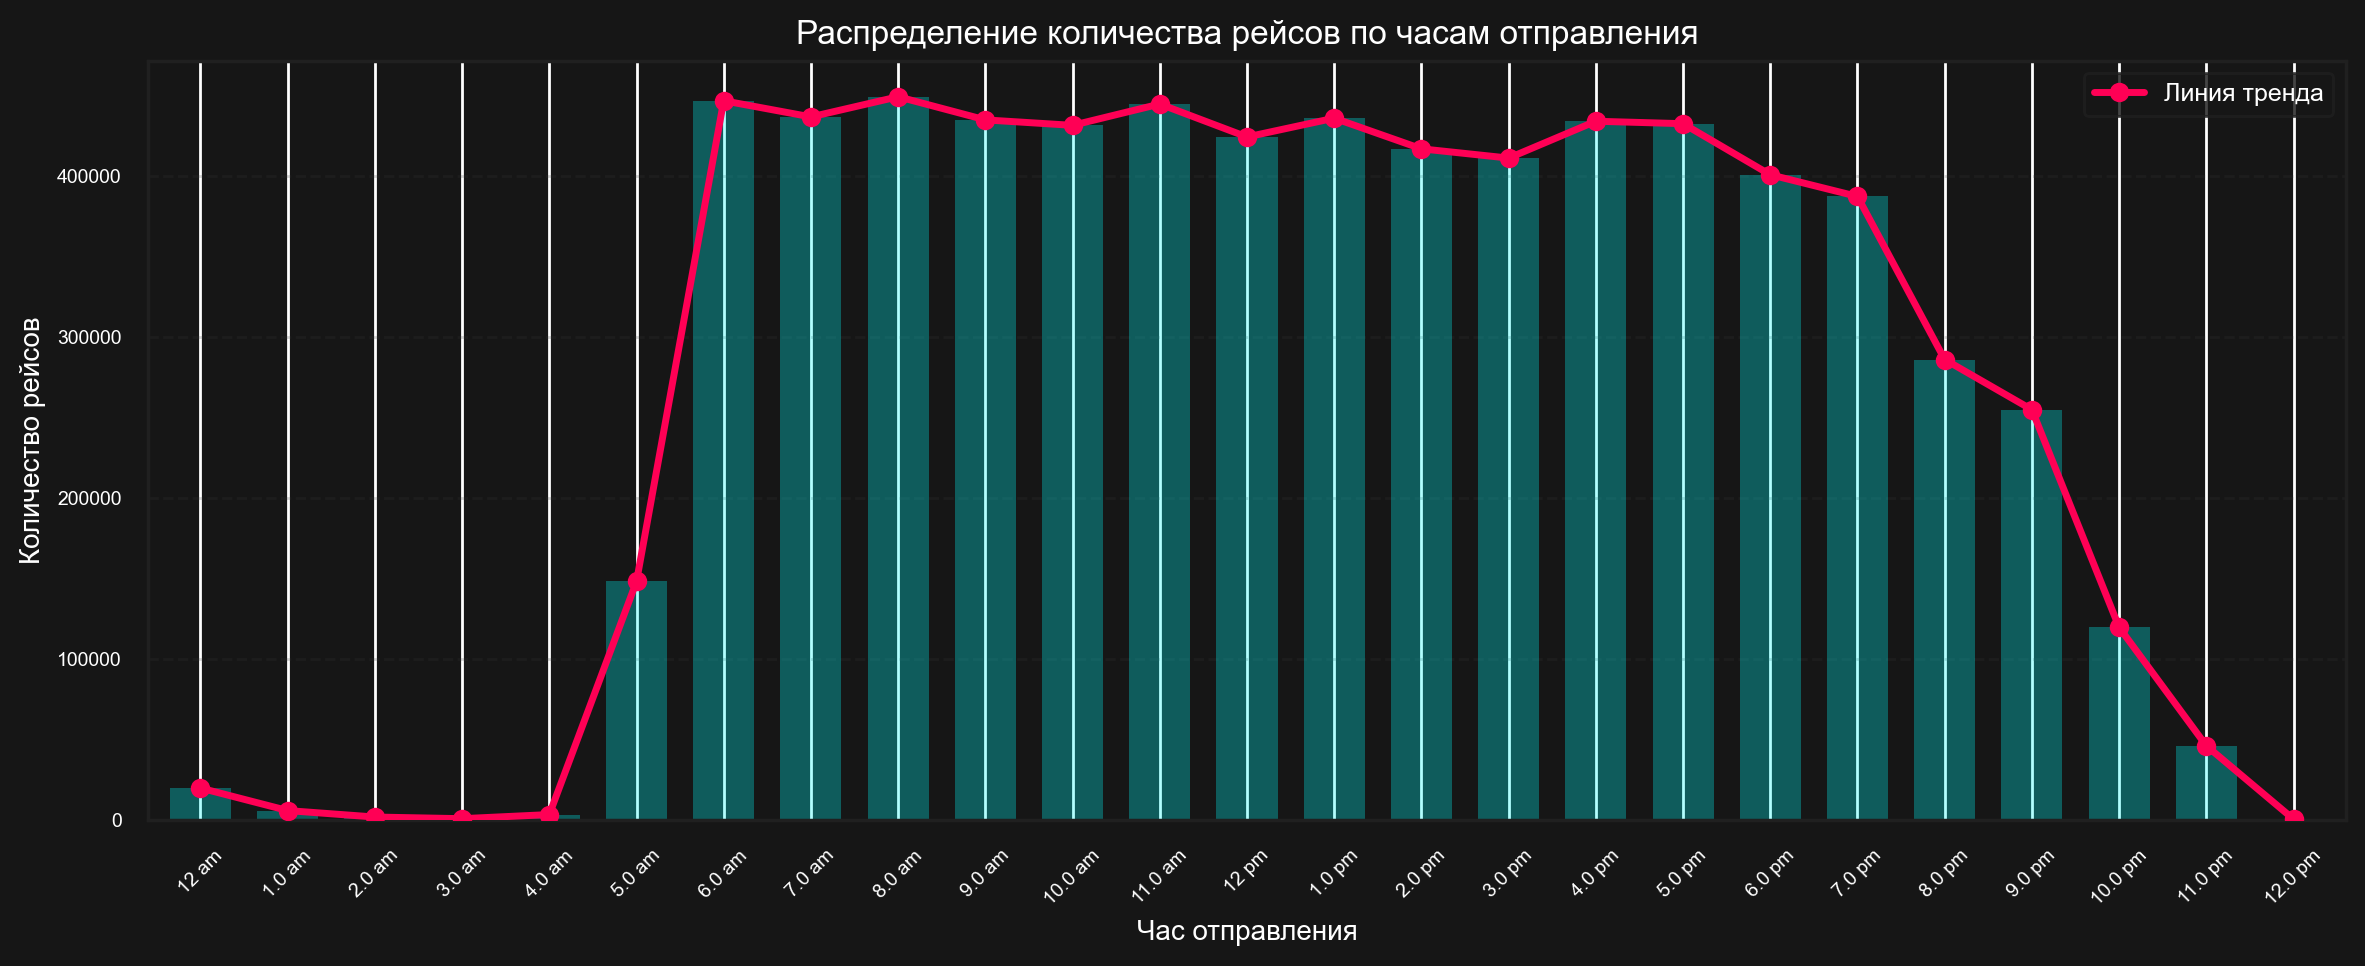


Проверка утверждений о распределении рейсов по часам:
- Кейсы НЕ равномерно распределены во временном интервале [0-23].
- В период с 0 до 4 утра рейсов значительно меньше, чем с 19:00 до 20:00.


In [94]:
hour_distribution = flights_df.groupby("DepHour").size()
print("\nРаспределение количества рейсов по часам отправления:")
for hour in range(24):
    print(f"{hour_to_ampm(hour)}: {hour_distribution.get(hour, 0)} рейсов")

# Построим график bar в seaborn
fig, ax = plt.subplots(figsize=(12, 5), facecolor="#161616")
ax.set_facecolor("#161616")

# Построение столбчатого графика
hour_distribution.plot(kind="bar", ax=ax, color="#00ffff", width=0.7, edgecolor='none', alpha=0.3, zorder=2)

# Добавляем линию распределения поверх столбцов
ax.plot(range(len(hour_distribution)), hour_distribution.values, color="#ff0055", linewidth=2.5, marker='o', markersize=6, zorder=3, label='Линия тренда')

# Оформление границ
for spine in ax.spines.values():
    spine.set_color("#202020")

# Оформление осей и текста
ax.set_xlabel("Час отправления", fontsize=10, color='white')
ax.set_ylabel("Количество рейсов", fontsize=10, color='white')
ax.set_title("Распределение количества рейсов по часам отправления", fontsize=12, color='white')
ax.set_xticklabels([hour_to_ampm(h) for h in hour_distribution.index], rotation=45, color='white', fontsize=7)
ax.tick_params(colors='white', labelsize=7)

# Легенда
ax.legend(fontsize=9, labelcolor='white', facecolor='#161616', edgecolor='#202020', loc='upper right')

# Сетка
ax.grid(True, alpha=0.2, color="#3b3b3b", linestyle='--', axis='y')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Выберите все верные утверждения:
# - Кейсы равномерно распределены во временном интервале [0-23].
# - В период с 0 до 4 утра рейсов значительно меньше, чем с 19:00 до 20:00.

print("\nПроверка утверждений о распределении рейсов по часам:")

# Проверяем равномерность распределения
is_uniform = hour_distribution.nunique() == 1
if is_uniform:
    print("- Кейсы равномерно распределены во временном интервале [0-23].")
else:
    print("- Кейсы НЕ равномерно распределены во временном интервале [0-23].")

# Проверяем количество рейсов в период с 0 до 4 утра и с 19:00 до 20:00
early_morning_flights = hour_distribution.loc[0:4].sum()
evening_flights = hour_distribution.loc[19:20].sum()
if early_morning_flights < evening_flights:
    print("- В период с 0 до 4 утра рейсов значительно меньше, чем с 19:00 до 20:00.")
else:
    print("- В период с 0 до 4 утра рейсов не меньше, чем с 19:00 до 20:00.")


**<font color='red'>Вопрос 15.</font> Покажите, как количество рейсов меняется со временем (ежедневно/еженедельно/ежемесячно) и интерпретируйте полученные результаты.**

**Выберите все правильные утверждения:**
- Количество рейсов в выходные дни меньше, чем в будние (рабочие дни).
- Наименьшее количество рейсов приходится на воскресенье.
- Зимой рейсов меньше, чем летом.

_Подсказка_: ищите официальные метеорологические зимние месяцы для Северного полушария.

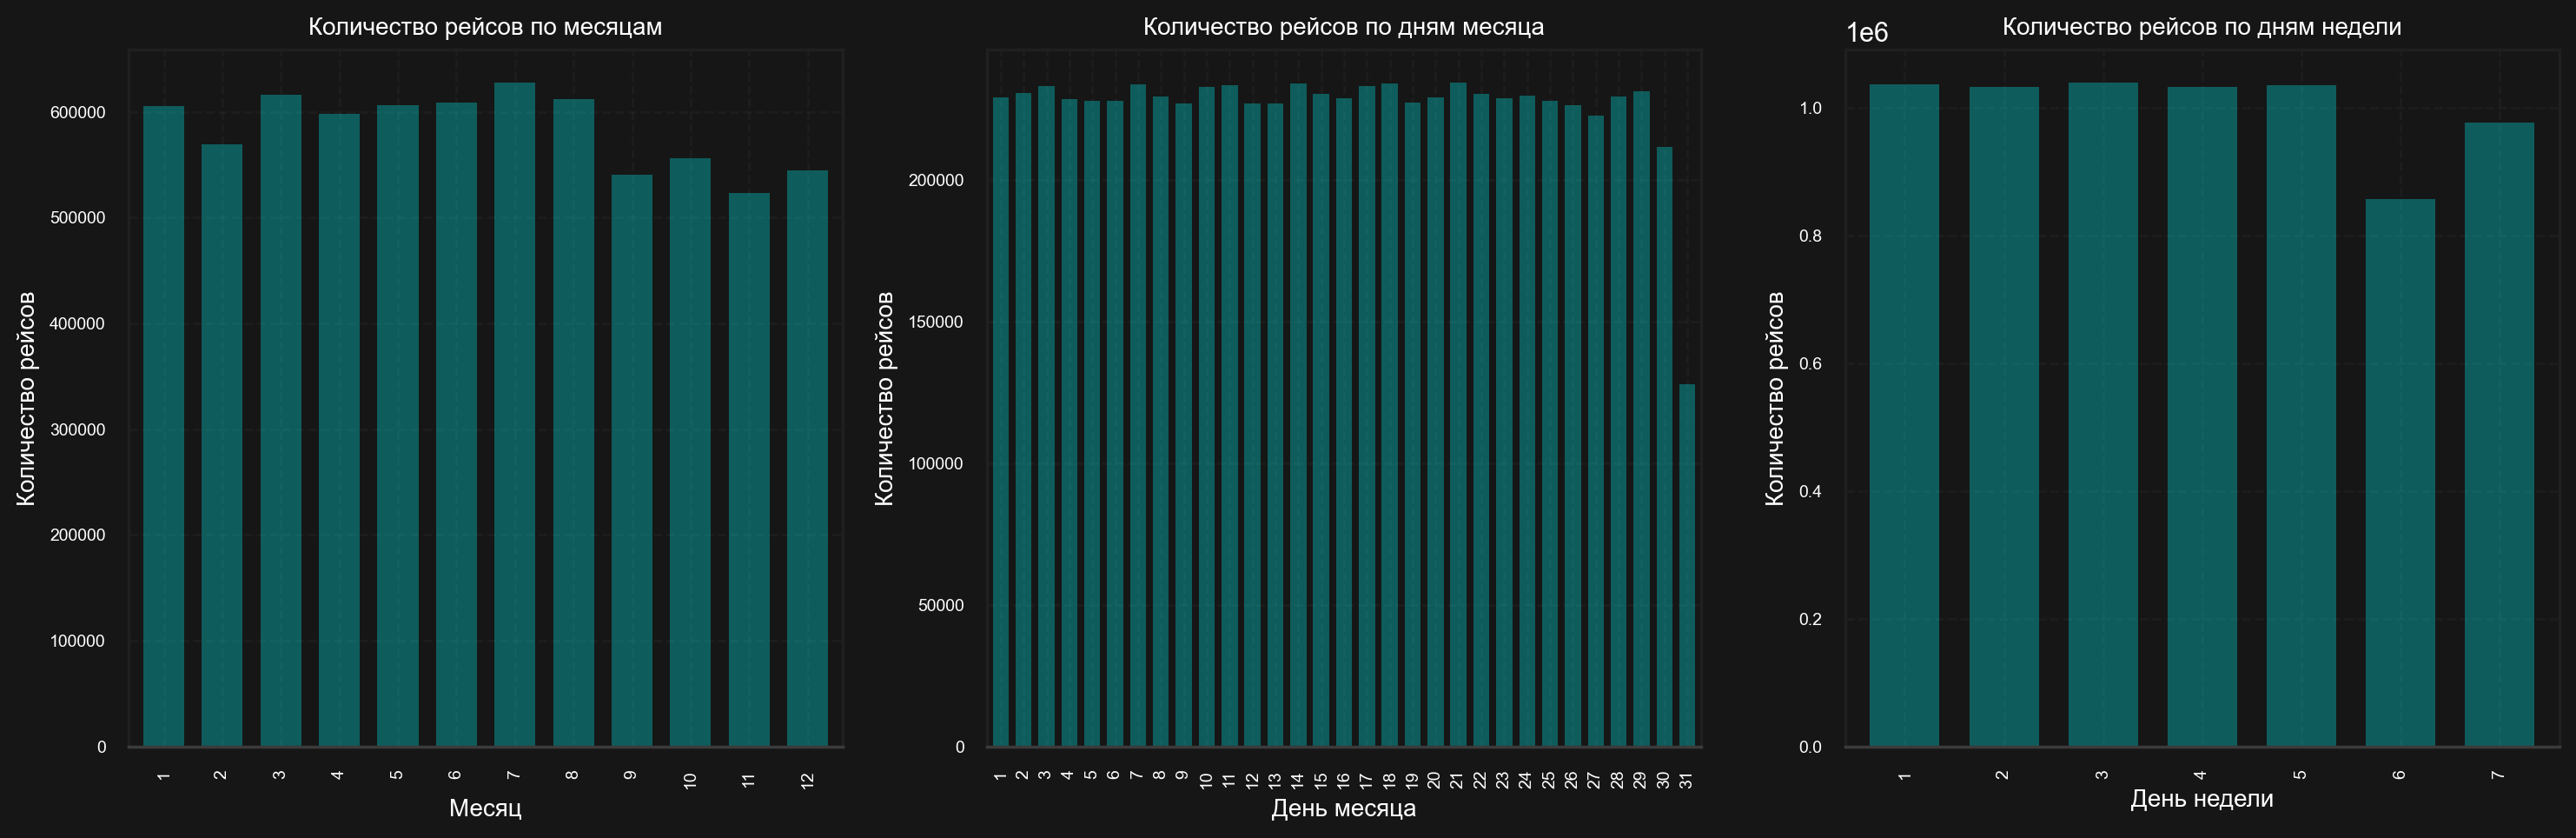

In [108]:
number_of_flights_by_month = flights_df.groupby("Month").size()
number_of_flights_by_day = flights_df.groupby("DayofMonth").size()
number_of_flight_by_week = flights_df.groupby("DayOfWeek").size()

# Построим 3 графика в одном окне
fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor="#161616")
for ax in axes:
    ax.set_facecolor("#161616")

# Построение столбчатого графика
ax1 = axes[0]
number_of_flights_by_month.plot(kind="bar", ax=ax1, color="#00ffff", width=0.7, edgecolor='none', alpha=0.3, zorder=2)
ax1.set_title("Количество рейсов по месяцам", fontsize=10, color='white')
ax1.set_xlabel("Месяц", fontsize=10, color='white')
ax1.set_ylabel("Количество рейсов", fontsize=10, color='white')

# Построение столбчатого графика
ax2 = axes[1]
number_of_flights_by_day.plot(kind="bar", ax=ax2, color="#00ffff", width=0.7, edgecolor='none', alpha=0.3, zorder=2)
ax2.set_title("Количество рейсов по дням месяца", fontsize=10, color='white')
ax2.set_xlabel("День месяца", fontsize=10, color='white')
ax2.set_ylabel("Количество рейсов", fontsize=10, color='white')

# Построение столбчатого графика
ax3 = axes[2]
number_of_flight_by_week.plot(kind="bar", ax=ax3, color="#00ffff", width=0.7, edgecolor='none', alpha=0.3, zorder=2)
ax3.set_title("Количество рейсов по дням недели", fontsize=10, color='white')
ax3.set_xlabel("День недели", fontsize=10, color='white')
ax3.set_ylabel("Количество рейсов", fontsize=10, color='white')

# Оформление границ
for ax in [ax1, ax2, ax3]:
    for spine in ax.spines.values():
        spine.set_color("#202020")

# Стиль текста
for ax in [ax1, ax2, ax3]:
    ax.tick_params(axis='x', labelsize=7, labelcolor='white')
    ax.tick_params(axis='y', labelsize=7, labelcolor='white')

# Сетка
for ax in [ax1, ax2, ax3]:
    ax.grid(True, alpha=0.2, color="#3b3b3b", linestyle='--', axis='y')
    ax.grid(True, alpha=0.2, color="#3b3b3b", linestyle='--', axis='x')

# Стиль графика
for ax in [ax1, ax2, ax3]:
    ax.spines['bottom'].set_color("#3b3b3b")

# Показываем графики
plt.tight_layout()
plt.show()

In [ ]:
check_if_flight_in_weekends_more_than_in_weekdays = flights_df['DayOfWeek'].value_counts()
if check_if_flight_in_weekends_more_than_in_weekdays[6] > check_if_flight_in_weekends_more_than_in_weekdays[5]:
    print("Количество рейсов в выходные дни меньше, чем в будние (рабочие дни)")
else:
    print("Количество рейсов в выходные дни больше, чем в будние (рабочие дни)")

Количество рейсов в выходные дни больше, чем в будние (рабочие дни)


In [114]:
day_names = {
    1: "Понедельник",
    2: "Вторник",
    3: "Среда",
    4: "Четверг",
    5: "Пятница",
    6: "Суббота",
    7: "Воскресенье"
}

# Создаем новую колонку с названиями дней
flights_df["DayName"] = flights_df["DayOfWeek"].map(day_names)

flights_by_day = flights_df.groupby("DayName").size()

day_with_fewest_flights = flights_by_day.idxmin()

print(f"День с наименьшим количеством рейсов: {day_with_fewest_flights}")

if day_with_fewest_flights == "Воскресенье":
    print("Утверждение подтверждено: наименьшее количество рейсов приходится на воскресенье.")
else:
    print(f"Утверждение не подтверждено: наименьшее количество рейсов приходится на {day_with_fewest_flights}.")

День с наименьшим количеством рейсов: Суббота
Утверждение не подтверждено: наименьшее количество рейсов приходится на Суббота.


In [115]:
# Зима: декабрь, январь, февраль
winter_flights = flights_df['Month'].isin([12, 1, 2]).sum()

# Лето: июнь, июль, август
summer_flights = flights_df['Month'].isin([6, 7, 8]).sum()

print(f"Количество рейсов зимой: {winter_flights}")
print(f"Количество рейсов летом: {summer_flights}")

if winter_flights < summer_flights:
    print("Утверждение подтверждено: зимой рейсов меньше, чем летом.")
else:
    print("Утверждение не подтверждено.")

Количество рейсов зимой: 1719959
Количество рейсов летом: 1848875
Утверждение подтверждено: зимой рейсов меньше, чем летом.


**<font color='red'>Вопрос 16.</font> Изучите распределение причин отмены во времени. Составьте диаграмму причин отмены, агрегированных по месяцам.**

**Выберите все правильные утверждения:**
- В октябре наименьшее количество отмен из-за погоды. 
- Наибольшее количество отмен в сентябре связано с соображениями безопасности.
- Основная причина отмены рейсов в апреле – операторы связи.
- Отмены рейсов по вине Национальной воздушной системы происходят чаще, чем по вине перевозчиков.

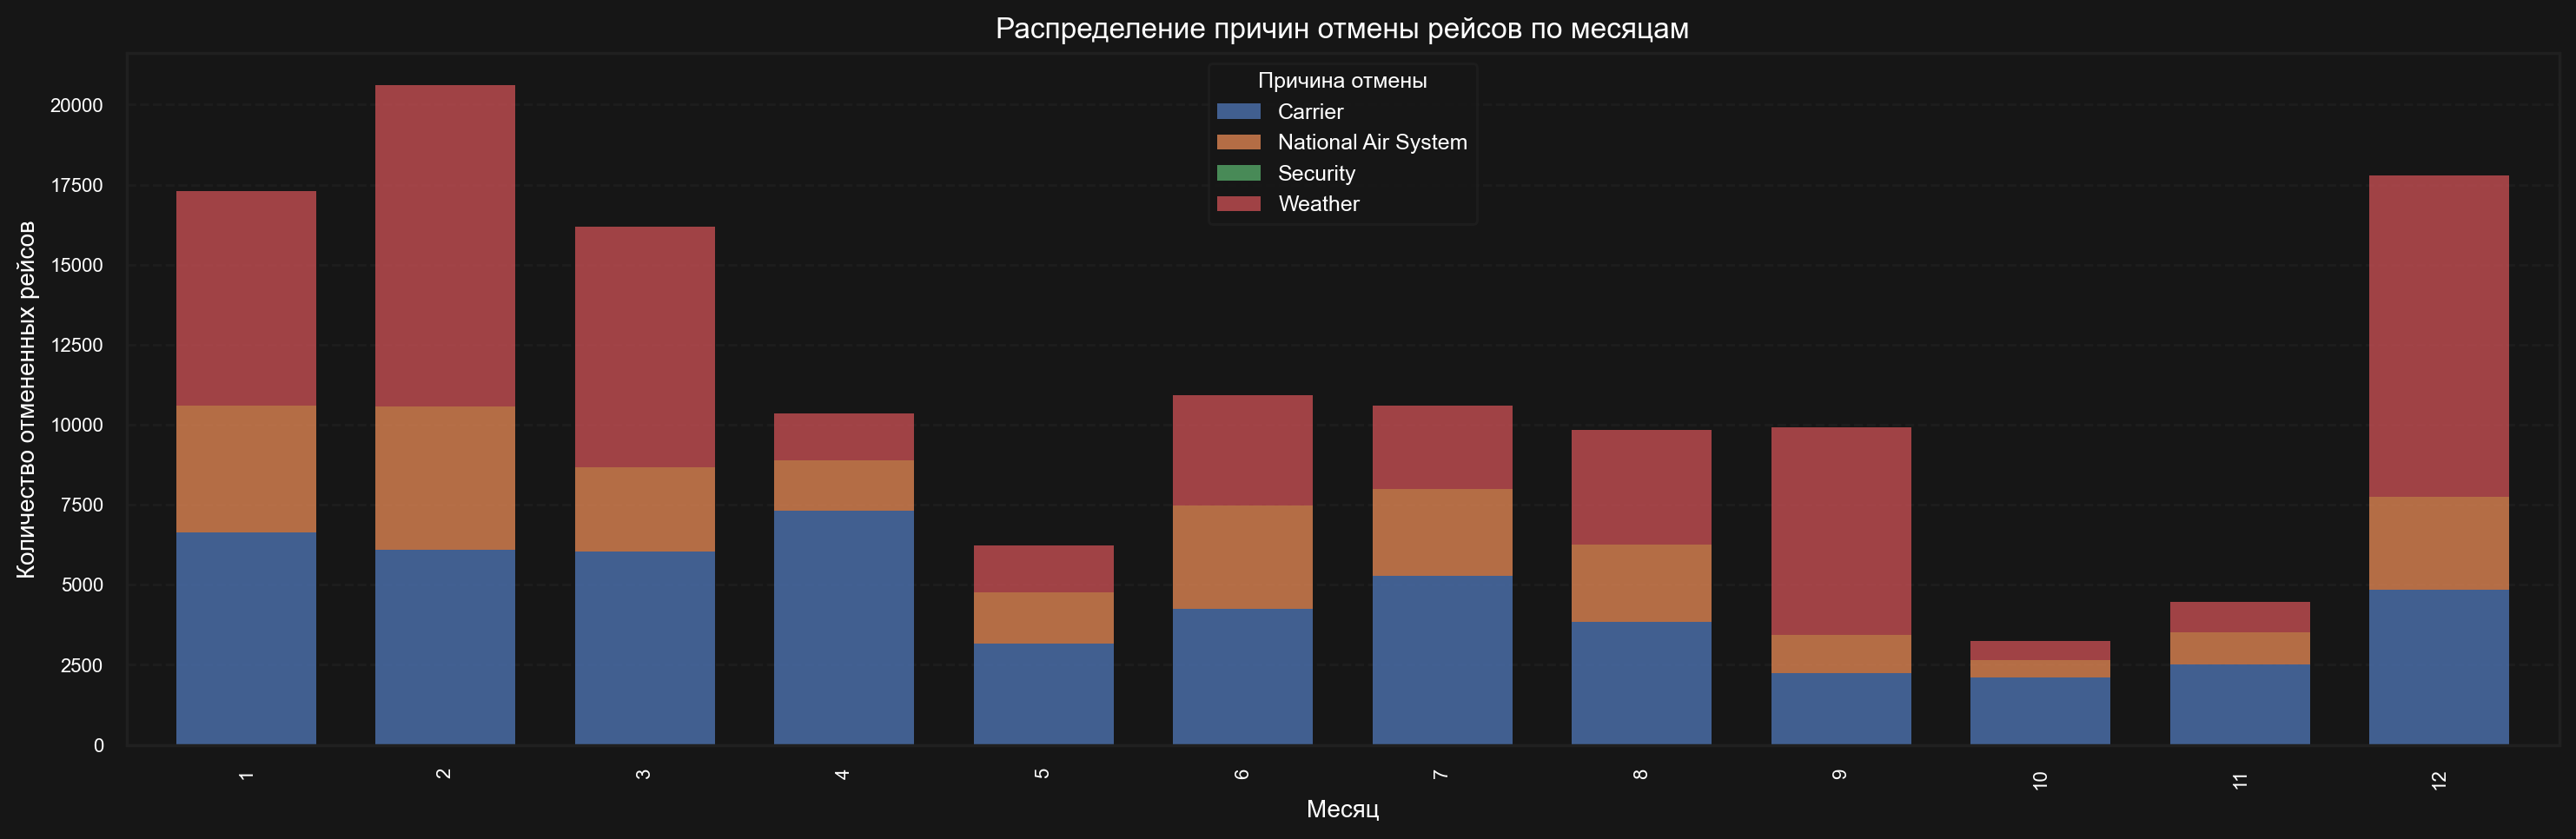

In [124]:
# Распределение причин отмены по месяцам

# Оставляем только отмененные рейсы, где есть причина отмены
cancelled_flights = flights_df[flights_df["CancellationCode"].notna()]

cancelled_flights = flights_df[
    flights_df["CancellationCode"].notna()
].copy()

cancellation_descriptions = {
    'A': 'Carrier',
    'B': 'Weather',
    'C': 'National Air System',
    'D': 'Security'
}

cancelled_flights["CancellationCode"] = (
    cancelled_flights["CancellationCode"]
    .map(cancellation_descriptions)
)


# Группируем данные по месяцу и причине отмены
cancellation_distribution = (
    cancelled_flights
    .groupby(["Month", "CancellationCode"])
    .size()
    .unstack(fill_value=0)
)

# Строим график
fig = plt.figure(figsize=(15, 5), facecolor="#161616")
ax = fig.add_subplot(111)
ax.set_facecolor("#161616")

cancellation_distribution.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.7,
    edgecolor="none",
    alpha=0.8,
    zorder=2
)

# Названия графика и осей
ax.set_title("Распределение причин отмены рейсов по месяцам", fontsize=12, color="white")
ax.set_xlabel("Месяц", fontsize=10, color="white")
ax.set_ylabel("Количество отмененных рейсов", fontsize=10, color="white")

# Оформление
for spine in ax.spines.values():
    spine.set_color("#202020")

ax.tick_params(axis="x", labelsize=8, labelcolor="white")
ax.tick_params(axis="y", labelsize=8, labelcolor="white")

ax.grid(True, alpha=0.2, color="#3b3b3b", linestyle="--", axis="y")
ax.grid(False, axis="x")
ax.set_axisbelow(True)

# Легенда
legend = ax.legend(
    title="Причина отмены",
    fontsize=9,
    title_fontsize=9,
    facecolor="#161616",
    edgecolor="#202020",
    labelcolor="white"
)

legend.get_title().set_color("white")

# Показываем график
plt.tight_layout()
plt.show()

In [125]:
# Считаем количество отмен из-за погоды по месяцам
weather_cancellations_by_month = flights_df[
    flights_df['CancellationCode'] == 'B'
].groupby('Month').size()

print(weather_cancellations_by_month)

# Месяц с минимальным количеством отмен из-за погоды
month_with_min_weather_cancellations = weather_cancellations_by_month.idxmin()

if month_with_min_weather_cancellations == 10:
    print("Утверждение подтверждено: в октябре наименьшее количество отмен из-за погоды.")
else:
    print(f"Утверждение не подтверждено: наименьшее количество отмен из-за погоды в месяце №{month_with_min_weather_cancellations}.")

Month
1      6711
2     10034
3      7520
4      1479
5      1461
6      3448
7      2612
8      3582
9      6478
10      600
11      937
12    10042
dtype: int64
Утверждение подтверждено: в октябре наименьшее количество отмен из-за погоды.


In [131]:
# Наибольшее количество отмен в сентябре связано с соображениями безопасности

check_if_flight_in_Semptember_due_to_security = (
    flights_df[flights_df['Month'] == 9]['CancellationCode']
    .value_counts()
)

print(check_if_flight_in_Semptember_due_to_security)

if check_if_flight_in_Semptember_due_to_security.idxmax() == 'D':
    print("Утверждение подтверждено: наибольшее количество отмен в сентябре связано с соображениями безопасности.")
else:
    print(
        f"Утверждение не подтверждено. Наибольшее количество отмен связано с причиной "
        f"{check_if_flight_in_Semptember_due_to_security.idxmax()}."
    )

CancellationCode
B    6478
A    2246
C    1188
D       1
Name: count, dtype: int64
Утверждение не подтверждено. Наибольшее количество отмен связано с причиной B.


In [ ]:
Main_reason_in_april = flights_df[flights_df['Month'] == 4]['CancellationCode'].value_counts()
print(Main_reason_in_april)

if Main_reason_in_april.idxmax() == 'A':
    print("Основная причина отмены рейсов в апреле – Авиаперевозчик")
else:
    print(f"Утверждение не подтверждено. Наибольшее количество отмен связано с причиной "
        f"{Main_reason_in_april.idxmax()}."
    )

CancellationCode
A    7312
C    1564
B    1479
Name: count, dtype: int64
Основная причина отмены рейсов в апреле – операторы связи


In [137]:
# Количество отмен по причинам
cancellation_counts = flights_df['CancellationCode'].value_counts()

print(cancellation_counts)

# Проверка утверждения
if cancellation_counts['C'] > cancellation_counts['A']:
    print("Утверждение подтверждено: отмены по вине National Air System происходят чаще, чем по вине Carrier.")
else:
    print("Утверждение не подтверждено: отмены по вине Carrier происходят чаще.")

CancellationCode
B    54904
A    54330
C    28188
D       12
Name: count, dtype: int64
Утверждение не подтверждено: отмены по вине Carrier происходят чаще.


**<font color='red'>Вопрос 17.</font> В каком месяце происходит наибольшее количество отмен по вине Carrier?**

- Май
- Январь
- Сентябрь
- Апрель

In [145]:
month_names = {
    1: "Январь",
    2: "Февраль",
    3: "Март",
    4: "Апрель",
    5: "Май",
    6: "Июнь",
    7: "Июль",
    8: "Август",
    9: "Сентябрь",
    10: "Октябрь",
    11: "Ноябрь",
    12: "Декабрь"
}

Flights_by_carrier = (
    flights_df[flights_df['CancellationCode'] == 'A']['Month']
    .value_counts()
)

month = Flights_by_carrier.idxmax()

print(f"Наибольшее количество отмен по вине Carrier происходит в месяце: {month_names[month]}")

Наибольшее количество отмен по вине Carrier происходит в месяце: Апрель


**<font color='red'>Вопрос 18.</font> Определите перевозчика с наибольшим количеством отмен из-за перевозчика в соответствующем месяце из предыдущего вопроса.**

- 9E
- EV
- HA
- AA

In [144]:
carrier_with_most_cancellations = (
    flights_df[flights_df['CancellationCode'] == 'A']['UniqueCarrier']
    .value_counts()
)

print(
    f"Перевозчик с наибольшим количеством отмен по причине Carrier: "
    f"{carrier_with_most_cancellations.idxmax()}"
)

Перевозчик с наибольшим количеством отмен по причине Carrier: AA
